<a href="https://colab.research.google.com/github/kenawnurum/myproject/blob/main/MTP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
import numpy as np
# Location & dates
latitude = 9
longitude = 39
start_date = "19860430"   # YYYYMMDD - Adjusted for ~40 years
end_date   = "20260504"   # YYYYMMDD -

parameters = "T2M_MIN,T2M_MAX,RH2M,ALLSKY_SFC_SW_DWN,WS2M,PRECTOTCORR"

url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters={parameters}&community=AG&longitude={longitude}&latitude={latitude}&start={start_date}&end={end_date}&format=JSON"

# Fetch data
response = requests.get(url)
data = response.json()

# 🔹 Extract elevation (from geometry -> coordinates[2])
try:
    elevation_m = data["geometry"]["coordinates"][2]
except:
    elevation_m = None
    print("⚠️ Elevation not found in response.")

# Parse JSON records
records = data['properties']['parameter']
dates = list(records['T2M_MIN'].keys())

# Build DataFrame
df = pd.DataFrame({
    'date': dates,
    'tmin_c': [records['T2M_MIN'][d] for d in dates],
    'tmax_c': [records['T2M_MAX'][d] for d in dates],
    'rh_percent': [records['RH2M'][d] for d in dates],
    'solar_rad_mj_m2': [records['ALLSKY_SFC_SW_DWN'][d] for d in dates],
    'wind_m_s': [records['WS2M'][d] for d in dates],
    'rain_mm': [records['PRECTOTCORR'][d] for d in dates]
})

# Convert date column
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# 🔹 Compute mean temperature
df['tavg_c'] = ((df['tmin_c'] + df['tmax_c']) / 2).round(2)

# 🔹 Add elevation (same for all rows at this location)
df['elevation_m'] = elevation_m

# Reorder columns
df = df[['date','tmin_c','tmax_c','tavg_c','rh_percent','solar_rad_mj_m2',
         'wind_m_s','rain_mm','elevation_m']]

# Show first rows

valid_ranges = {
    'tmin_c': (-40, 45),
    'tmax_c': (-30, 55),
    'tavg_c': (-40, 50),
    'rh_percent': (0, 100),
    'solar_rad_mj_m2': (0, 35),   # adjust if your site has higher solar radiation
    'wind_m_s': (0, 40),
    'rain_mm': (0, 500)          # depends on the region
}


#df.replace(-999, np.nan, inplace=True)

for col, (low, high) in valid_ranges.items():
    df[col] = df[col].mask( (df[col] < low) | (df[col] > high) )

print(df.head())
print('\n')
print(df.tail())

        date  tmin_c  tmax_c  tavg_c  rh_percent  solar_rad_mj_m2  wind_m_s  \
0 1986-04-30   11.16   24.91   18.04       65.41            25.43      0.88   
1 1986-05-01   12.37   24.44   18.40       74.90            24.52      1.33   
2 1986-05-02   11.12   26.10   18.61       67.43            24.42      1.58   
3 1986-05-03   12.04   25.22   18.63       70.36            23.28      1.37   
4 1986-05-04   13.34   25.03   19.19       69.73            22.13      1.50   

   rain_mm  elevation_m  
0     2.24      2349.69  
1     1.26      2349.69  
2     0.50      2349.69  
3     3.78      2349.69  
4     2.05      2349.69  


            date  tmin_c  tmax_c  tavg_c  rh_percent  solar_rad_mj_m2  \
14610 2026-04-30   14.05   25.53   19.79       61.02            21.38   
14611 2026-05-01   14.33   26.70   20.52       56.31            19.03   
14612 2026-05-02   14.25   25.50   19.88       58.15            19.97   
14613 2026-05-03   13.37   24.60   18.98       66.36            21.18   
14

#Data preprocessing

In [ ]:
def smart_fill(col):
    s = col.copy()
    isna = s.isna()

    # group consecutive NaN blocks
    grp = (isna != isna.shift()).cumsum()

    for g in grp[isna].unique():
        idx = s.index[grp == g]
        length = len(idx)

        if length == 1:
            # forward fill 1-day missing
            s.loc[idx] = s.ffill().loc[idx]
        else:
            # time-based interpolation
            s = s.interpolate(method='time')

    return s


df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

valid_ranges = {
    'tmin_c': (-40, 45),
    'tmax_c': (-30, 55),
    'tavg_c': (-40, 50),
    'rh_percent': (0, 100),
    'solar_rad_mj_m2': (0, 35),
    'wind_m_s': (0, 40),
    'rain_mm': (0, 500)          # depends on the region
}

weather_cols = list(valid_ranges.keys())

for col in weather_cols:
    df[col] = smart_fill(df[col])
df.to_csv("nasa_power_weather.csv", index=False)
print(f"✅ Saved to nasa_power_weather_with_elevation.csv with elevation = {elevation_m} m")



print(df.head())
print('\n')
print(df.tail())

✅ Saved to nasa_power_weather_with_elevation.csv with elevation = 2349.69 m
            tmin_c  tmax_c  tavg_c  rh_percent  solar_rad_mj_m2  wind_m_s  \
date                                                                        
1986-04-30   11.16   24.91   18.04       65.41            25.43      0.88   
1986-05-01   12.37   24.44   18.40       74.90            24.52      1.33   
1986-05-02   11.12   26.10   18.61       67.43            24.42      1.58   
1986-05-03   12.04   25.22   18.63       70.36            23.28      1.37   
1986-05-04   13.34   25.03   19.19       69.73            22.13      1.50   

            rain_mm  elevation_m  
date                              
1986-04-30     2.24      2349.69  
1986-05-01     1.26      2349.69  
1986-05-02     0.50      2349.69  
1986-05-03     3.78      2349.69  
1986-05-04     2.05      2349.69  


            tmin_c  tmax_c  tavg_c  rh_percent  solar_rad_mj_m2  wind_m_s  \
date                                                        

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14615 entries, 1986-04-30 to 2026-05-04
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tmin_c           14615 non-null  float64
 1   tmax_c           14615 non-null  float64
 2   tavg_c           14615 non-null  float64
 3   rh_percent       14615 non-null  float64
 4   solar_rad_mj_m2  14615 non-null  float64
 5   wind_m_s         14615 non-null  float64
 6   rain_mm          14615 non-null  float64
 7   elevation_m      14615 non-null  float64
dtypes: float64(8)
memory usage: 1.5 MB


#ET0 Computation

In [ ]:
import pandas as pd
import numpy as np

# df is available from previous cells, with 'date' as index.

# === 1️⃣ & 2️⃣ Convert and rename columns ===
df.rename(columns={
    "tmax_c": "Tmax",
    "tmin_c": "Tmin",
    "rh_percent": "RH",
    "solar_rad_mj_m2": "Rs",
    "wind_m_s": "u2"
}, inplace=True)

# === 3️⃣ Define constants ===
G = 0                      # Soil heat flux (MJ/m²/day)
λ = 2.45                   # Latent heat of vaporization (MJ/kg)
P = 101.3                  # Atmospheric pressure (kPa)
γ = 0.000665 * P           # Psychrometric constant (kPa/°C)

# === 4️⃣ Define FAO-56 Penman–Monteith function ===
def eto_fao56(Tmax, Tmin, u2, Rs, RH):
    Tmean = (Tmax + Tmin) / 2  # Mean air temperature (°C)

    # Saturation vapor pressure (kPa)
    es_Tmax = 0.6108 * np.exp((17.27 * Tmax) / (Tmax + 237.3))
    es_Tmin = 0.6108 * np.exp((17.27 * Tmin) / (Tmin + 237.3))
    es = (es_Tmax + es_Tmin) / 2

    # Actual vapor pressure (ea) from RH (%)
    ea = es * (RH / 100.0)

    # Slope of vapor pressure curve (kPa/°C)
    delta = 4098 * (0.6108 * np.exp((17.27 * Tmean) / (Tmean + 237.3))) / (Tmean + 237.3) ** 2

    # Approximate net radiation (MJ/m²/day)
    Rn = Rs * 0.77

    # FAO-56 Penman–Monteith equation
    ET0 = (0.408 * delta * (Rn - G) + γ * (900 / (Tmean + 273)) * u2 * (es - ea)) / \
          (delta + γ * (1 + 0.34 * u2))
    return ET0

# === 5️⃣ Apply function to calculate ET₀ ===
df["ET0_FAO56"] = df.apply(lambda x: eto_fao56(x["Tmax"], x["Tmin"], x["u2"], x["Rs"], x["RH"]), axis=1)

# === 6️⃣ Save to new CSV ===
# Reset index to save 'date' as a column, and rename it to 'Date' for consistency
df_to_save = df.reset_index().rename(columns={'date': 'Date'})
output_file = "nasa_power_weather_with_ET0.csv"
df_to_save.to_csv(output_file, index=False)

print("✅ ET₀ calculated and saved successfully!")
print(f"📁 Output file: {output_file}")
print(df.head())

✅ ET₀ calculated and saved successfully!
📁 Output file: nasa_power_weather_with_ET0.csv
             Tmin   Tmax  tavg_c     RH     Rs    u2  rain_mm  elevation_m  \
date                                                                         
1986-04-30  11.16  24.91   18.04  65.41  25.43  0.88     2.24      2349.69   
1986-05-01  12.37  24.44   18.40  74.90  24.52  1.33     1.26      2349.69   
1986-05-02  11.12  26.10   18.61  67.43  24.42  1.58     0.50      2349.69   
1986-05-03  12.04  25.22   18.63  70.36  23.28  1.37     3.78      2349.69   
1986-05-04  13.34  25.03   19.19  69.73  22.13  1.50     2.05      2349.69   

            ET0_FAO56  
date                   
1986-04-30   5.427542  
1986-05-01   5.112176  
1986-05-02   5.388817  
1986-05-03   5.051166  
1986-05-04   4.930808  


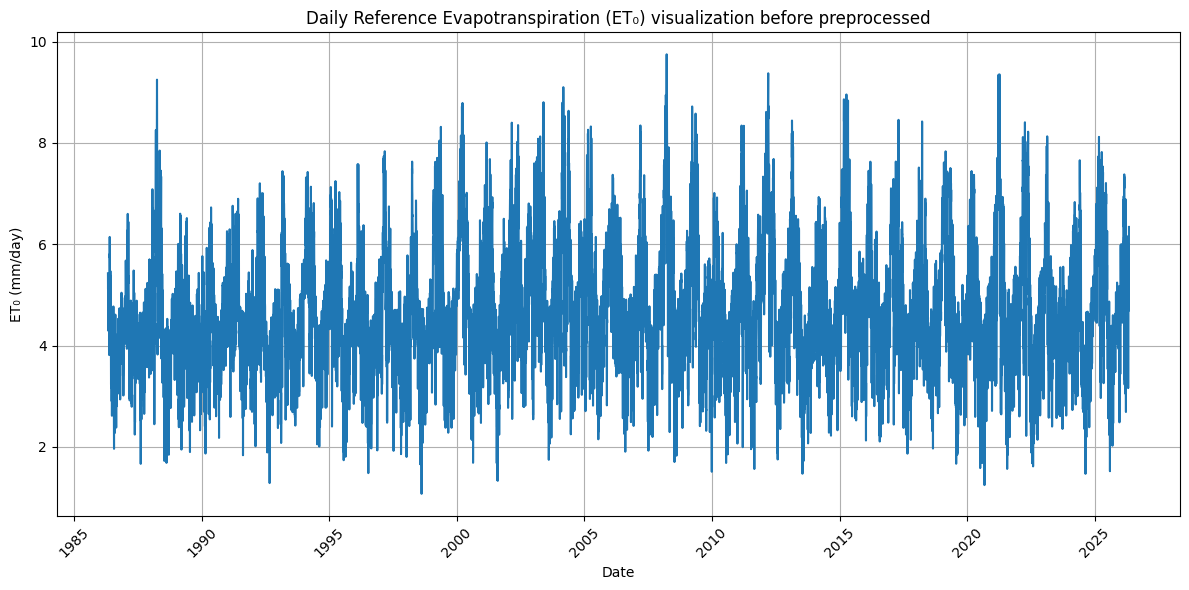

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset the index to make 'date' a column again before plotting
df_plot = df.reset_index()

# Ensure 'date' column is datetime type for plotting (already handled by reset_index()
# but good practice to ensure)
df_plot['date'] = pd.to_datetime(df_plot['date'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='ET0_FAO56', data=df_plot)
plt.title('Daily Reference Evapotranspiration (ET₀) visualization before preprocessed')
plt.xlabel('Date')
plt.ylabel('ET₀ (mm/day)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install mlflow
import mlflow

mlflow.set_tracking_uri(
    "file:/content/drive/MyDrive/mlruns"
)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14615 entries, 1986-04-30 to 2026-05-04
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Tmin         14615 non-null  float64
 1   Tmax         14615 non-null  float64
 2   tavg_c       14615 non-null  float64
 3   RH           14615 non-null  float64
 4   Rs           14615 non-null  float64
 5   u2           14615 non-null  float64
 6   rain_mm      14615 non-null  float64
 7   elevation_m  14615 non-null  float64
 8   ET0_FAO56    14615 non-null  float64
dtypes: float64(9)
memory usage: 1.6 MB


#Select input and target

In [ ]:
features = [
    "Tmin",
    "Tmax",
    "tavg_c",
    "RH",
    "Rs",
    "u2",
    "rain_mm"
]

target = "ET0_FAO56"

X = df[features]
y = df[target]

#Train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Set up ml flow

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("ETo_prediction")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///content/drive/MyDrive/mlruns/655741253316010463', creation_time=1773342608634, experiment_id='655741253316010463', last_update_time=1773342608634, lifecycle_stage='active', name='ETo_prediction', tags={}, trace_location=None, workspace='default'>

In [ ]:
mlflow.set_tracking_uri("file:/content/mlruns")

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

k = 5

# where the experiment 'ETo_prediction' was originally created.
mlflow.set_tracking_uri("file:/content/drive/MyDrive/mlruns")

with mlflow.start_run():

    model = KNeighborsRegressor(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    # Calculate RMSE by taking the square root of MSE
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    mlflow.log_param("k", k)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)

    mlflow.sklearn.log_model(model, "knn_model")

print("RMSE:", rmse)
print("R2:", r2)

2026/05/13 14:13:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:13:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 0.10137216924606461
R2: 0.9933438497213551


In [ ]:
for k in [3,5,7,9]:

    with mlflow.start_run():

        model = KNeighborsRegressor(n_neighbors=k)

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        # Calculate RMSE by taking the square root of MSE
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        mlflow.log_param("k", k)
        mlflow.log_metric("rmse", rmse)

#Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import mlflow
import mlflow.sklearn

In [ ]:
n_trees = 100
depth = 10

with mlflow.start_run():

    model = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    # Calculate RMSE by taking the square root of MSE
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    mlflow.log_param("n_estimators", n_trees)
    mlflow.log_param("max_depth", depth)

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)

    mlflow.sklearn.log_model(model, "rf_model")

print("RMSE:", rmse)
print("R2:", r2)

2026/05/13 14:14:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:14:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 0.0906434390648549
R2: 0.9946782019779777


In [ ]:
for n_trees in [50, 100, 200]:
    for depth in [5, 10, 15]:

        with mlflow.start_run():

            model = RandomForestRegressor(
                n_estimators=n_trees,
                max_depth=depth,
                random_state=42
            )

            model.fit(X_train, y_train)

            pred = model.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, pred))

            mlflow.log_param("n_estimators", n_trees)
            mlflow.log_param("max_depth", depth)

            mlflow.log_metric("rmse", rmse)

In [ ]:
import pickle
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Re-generate df_loaded if nasa_power_weather_with_ET0.csv is not found ---
# This part ensures the data is correctly prepared for model training/saving.

try:
    df_loaded = pd.read_csv('nasa_power_weather_with_ET0.csv')
    df_loaded['Date'] = pd.to_datetime(df_loaded['Date']) # Ensure Date is datetime
except FileNotFoundError:
    print("nasa_power_weather_with_ET0.csv not found. Re-generating DataFrame from source.")

    # --- Start of Data Generation (incorporating OL0GEuEaTU7U, CaK_nTYRTxQp, 4gva1HXAWJkm logic) ---
    import requests
    # Location & dates (hardcoding for self-containment, these were global variables previously)
    latitude = 9
    longitude = 39
    start_date = "19860430"   # YYYYMMDD - Adjusted for ~40 years
    end_date   = "20260430"   # YYYYMMDD

    parameters = "T2M_MIN,T2M_MAX,RH2M,ALLSKY_SFC_SW_DWN,WS2M,PRECTOTCORR"

    url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters={parameters}&community=AG&longitude={longitude}&latitude={latitude}&start={start_date}&end={end_date}&format=JSON"

    # Fetch data
    response = requests.get(url)
    data = response.json()

    # 🔹 Extract elevation (from geometry -> coordinates[2])
    try:
        elevation_m = data["geometry"]["coordinates"][2]
    except:
        elevation_m = None
        print("⚠️ Elevation not found in response.")

    # Parse JSON records
    records = data['properties']['parameter']
    dates = list(records['T2M_MIN'].keys())

    # Build DataFrame
    temp_df = pd.DataFrame({
        'date': dates,
        'tmin_c': [records['T2M_MIN'][d] for d in dates],
        'tmax_c': [records['T2M_MAX'][d] for d in dates],
        'rh_percent': [records['RH2M'][d] for d in dates],
        'solar_rad_mj_m2': [records['ALLSKY_SFC_SW_DWN'][d] for d in dates],
        'wind_m_s': [records['WS2M'][d] for d in dates],
        'rain_mm': [records['PRECTOTCORR'][d] for d in dates]
    })

    # Convert date column
    temp_df['date'] = pd.to_datetime(temp_df['date'], format='%Y%m%d')

    # 🔹 Compute mean temperature
    temp_df['tavg_c'] = ((temp_df['tmin_c'] + temp_df['tmax_c']) / 2).round(2)

    # 🔹 Add elevation (same for all rows at this location)
    temp_df['elevation_m'] = elevation_m

    # Reorder columns
    temp_df = temp_df[['date','tmin_c','tmax_c','tavg_c','rh_percent','solar_rad_mj_m2',
                     'wind_m_s','rain_mm','elevation_m']]

    # Filter out invalid ranges
    valid_ranges = {
        'tmin_c': (-40, 45),
        'tmax_c': (-30, 55),
        'tavg_c': (-40, 50),
        'rh_percent': (0, 100),
        'solar_rad_mj_m2': (0, 35),
        'wind_m_s': (0, 40),
        'rain_mm': (0, 500)
    }
    for col_name, (low, high) in valid_ranges.items():
        temp_df[col_name] = temp_df[col_name].mask( (temp_df[col_name] < low) | (temp_df[col_name] > high) )

    # --- smart_fill function (from CaK_nTYRTxQp) ---
    def smart_fill(col_series):
        s = col_series.copy()
        isna = s.isna()

        # group consecutive NaN blocks
        grp = (isna != isna.shift()).cumsum()

        for g in grp[isna].unique():
            idx = s.index[grp == g]
            length = len(idx)

            if length == 1:
                # forward fill 1-day missing
                s.loc[idx] = s.ffill().loc[idx]
            else:
                # time-based interpolation
                s = s.interpolate(method='time')
        return s

    temp_df = temp_df.set_index('date')
    weather_cols = list(valid_ranges.keys())
    for col_name in weather_cols:
        temp_df[col_name] = smart_fill(temp_df[col_name])

    # --- ET0 Computation (from 4gva1HXAWJkm) ---
    # Rename columns for ET0 function
    temp_df.rename(columns={
        "tmax_c": "Tmax",
        "tmin_c": "Tmin",
        "rh_percent": "RH",
        "solar_rad_mj_m2": "Rs",
        "wind_m_s": "u2"
    }, inplace=True)

    # Define constants
    G = 0                      # Soil heat flux (MJ/m²/day)
    λ = 2.45                   # Latent heat of vaporization (MJ/kg)
    P = 101.3                  # Atmospheric pressure (kPa)
    γ = 0.000665 * P           # Psychrometric constant (kPa/°C)

    # Define FAO-56 Penman–Monteith function
    def eto_fao56(Tmax, Tmin, u2, Rs, RH):
        Tmean = (Tmax + Tmin) / 2  # Mean air temperature (°C)
        es_Tmax = 0.6108 * np.exp((17.27 * Tmax) / (Tmax + 237.3))
        es_Tmin = 0.6108 * np.exp((17.27 * Tmin) / (Tmin + 237.3))
        es = (es_Tmax + es_Tmin) / 2

        # Actual vapor pressure (ea) from RH (%)
        ea = es * (RH / 100.0)

        # Slope of vapor pressure curve (kPa/°C)
        delta = 4098 * (0.6108 * np.exp((17.27 * Tmean) / (Tmean + 237.3))) / (Tmean + 237.3) ** 2

        # Approximate net radiation (MJ/m²/day)
        Rn = Rs * 0.77

        # FAO-56 Penman–Monteith equation
        ET0 = (0.408 * delta * (Rn - G) + γ * (900 / (Tmean + 273)) * u2 * (es - ea)) / \
              (delta + γ * (1 + 0.34 * u2))
        return ET0

    temp_df["ET0_FAO56"] = temp_df.apply(lambda x: eto_fao56(x["Tmax"], x["Tmin"], x["u2"], x["Rs"], x["RH"]), axis=1)

    # Reset index and rename 'date' column to 'Date' to match previous saving format
    temp_df = temp_df.reset_index().rename(columns={'index': 'Date'})

    df_loaded = temp_df.copy() # Assign the generated dataframe to df_loaded
    # --- End of Data Generation ---


# Define features and target (matching previous definitions)
features = [
    "Tmin",
    "Tmax",
    "tavg_c",
    "RH",
    "Rs",
    "u2",
    "rain_mm"
]
target = "ET0_FAO56"

# Ensure 'Date' column is not used as a feature and remove it if it exists in features
# The Date column is renamed to 'Date' from 'date' after reset_index()
# It is not intended to be a feature.
if 'Date' in df_loaded.columns:
    # Check if 'Date' was accidentally included in features for any reason
    if 'Date' in features:
        features.remove('Date')

X = df_loaded[features]
y = df_loaded[target]

# Perform train-test split (re-using the same random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and fit the StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Transform X_test as well, though not strictly needed for saving model/scaler

# Re-define and train the Random Forest model
# This uses the parameters from the last explicitly trained model (n_estimators=200, max_depth=10)
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# Save the trained Random Forest model
model_filename = 'random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

# Save the StandardScaler object
scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

print(f"✅ Random Forest model saved as {model_filename}")
print(f"✅ StandardScaler saved as {scaler_filename}")

✅ Random Forest model saved as random_forest_model.pkl
✅ StandardScaler saved as scaler.pkl


### Load and Use the Saved Model and Scaler for New Data

Now that we have saved our model and scaler, we can load them to make predictions on new data. This is crucial for deployment, as you won't need to re-train the model every time.

In [ ]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler # For type hinting, not strictly necessary for loading
from sklearn.ensemble import RandomForestRegressor # For type hinting
import requests

# --- 1. Load the saved model and scaler ---
with open('random_forest_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

with open('scaler.pkl', 'rb') as scaler_file:
    loaded_scaler = pickle.load(scaler_file)

print("✅ Model and Scaler loaded successfully!")

# --- 2. Fetch new 'live' weather data ---
# For demonstration, we'll fetch data for a slightly different time period or location.
# In a real application, this would be actual new, incoming weather data.
new_latitude = 9
new_longitude = 39
new_start_date = "20260313" # Start right after our training data ends
new_end_date   = "20260412" # Fetch data for one month

parameters = "T2M_MIN,T2M_MAX,RH2M,ALLSKY_SFC_SW_DWN,WS2M,PRECTOTCORR"

url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters={parameters}&community=AG&longitude={new_longitude}&latitude={new_latitude}&start={new_start_date}&end={new_end_date}&format=JSON"

response = requests.get(url)
new_data_raw = response.json()

# --- 3. Process the new raw data (similar to initial data preparation) ---
try:
    new_elevation_m = new_data_raw["geometry"]["coordinates"][2]
except:
    new_elevation_m = None
    print("⚠️ Elevation not found in new data response.")

records = new_data_raw['properties']['parameter']
dates = list(records['T2M_MIN'].keys())

new_df = pd.DataFrame({
    'date': dates,
    'tmin_c': [records['T2M_MIN'][d] for d in dates],
    'tmax_c': [records['T2M_MAX'][d] for d in dates],
    'rh_percent': [records['RH2M'][d] for d in dates],
    'solar_rad_mj_m2': [records['ALLSKY_SFC_SW_DWN'][d] for d in dates],
    'wind_m_s': [records['WS2M'][d] for d in dates],
    'rain_mm': [records['PRECTOTCORR'][d] for d in dates]
})

new_df['date'] = pd.to_datetime(new_df['date'], format='%Y%m%d')
new_df['tavg_c'] = ((new_df['tmin_c'] + new_df['tmax_c']) / 2).round(2)
new_df['elevation_m'] = new_elevation_m

# Reorder columns to match the training data's feature order
new_df = new_df[['date','tmin_c','tmax_c','tavg_c','rh_percent','solar_rad_mj_m2',
                 'wind_m_s','rain_mm','elevation_m']]

# Filter out invalid ranges (using the same ranges as training)
valid_ranges = {
    'tmin_c': (-40, 45),
    'tmax_c': (-30, 55),
    'tavg_c': (-40, 50),
    'rh_percent': (0, 100),
    'solar_rad_mj_m2': (0, 35),
    'wind_m_s': (0, 40),
    'rain_mm': (0, 500)
}
for col_name, (low, high) in valid_ranges.items():
    new_df[col_name] = new_df[col_name].mask( (new_df[col_name] < low) | (new_df[col_name] > high) )

# Apply smart_fill function (need to re-define or ensure it's in scope)
def smart_fill(col_series):
    s = col_series.copy()
    isna = s.isna()
    grp = (isna != isna.shift()).cumsum()
    for g in grp[isna].unique():
        idx = s.index[grp == g]
        length = len(idx)
        if length == 1:
            s.loc[idx] = s.ffill().loc[idx]
        else:
            s = s.interpolate(method='time')
    return s

new_df = new_df.set_index('date')
weather_cols_for_fill = list(valid_ranges.keys())
for col_name in weather_cols_for_fill:
    new_df[col_name] = smart_fill(new_df[col_name])

# Rename columns to match the features expected by the model (Tmin, Tmax, RH, Rs, u2)
new_df.rename(columns={
    "tmax_c": "Tmax",
    "tmin_c": "Tmin",
    "rh_percent": "RH",
    "solar_rad_mj_m2": "Rs",
    "wind_m_s": "u2"
}, inplace=True)

# Ensure the features are in the exact order the model was trained on
model_features = [
    "Tmin", "Tmax", "tavg_c", "RH", "Rs", "u2", "rain_mm"
]
X_new = new_df[model_features]

# --- 4. Scale the new data using the loaded scaler ---
X_new_scaled = loaded_scaler.transform(X_new)

print("✅ New data fetched, preprocessed, and scaled.")
print("New data head:")
print(X_new.head())

# --- 5. Make predictions with the loaded model ---
new_predictions = loaded_model.predict(X_new_scaled)

# Add predictions to the DataFrame for easier viewing
new_df['Predicted_ET0_FAO56'] = new_predictions

print("✅ Predictions made for new data.")
print("New data with predictions head:")
print(new_df[['Tmin', 'Tmax', 'RH', 'Rs', 'u2', 'Predicted_ET0_FAO56']].head())


✅ Model and Scaler loaded successfully!
✅ New data fetched, preprocessed, and scaled.
New data head:
             Tmin   Tmax  tavg_c     RH     Rs    u2  rain_mm
date                                                         
2026-03-13  12.79  23.73   18.26  69.92  20.34  1.98     0.54
2026-03-14  11.92  25.83   18.88  57.39  24.14  2.74     0.17
2026-03-15   9.74  26.99   18.36  48.40  26.86  2.64     0.00
2026-03-16   9.31  27.48   18.40  54.44  25.23  2.59     0.00
2026-03-17  10.99  28.05   19.52  52.06  23.39  2.43     0.03
✅ Predictions made for new data.
New data with predictions head:
             Tmin   Tmax     RH     Rs    u2  Predicted_ET0_FAO56
date                                                             
2026-03-13  12.79  23.73  69.92  20.34  1.98             4.456039
2026-03-14  11.92  25.83  57.39  24.14  2.74             5.991634
2026-03-15   9.74  26.99  48.40  26.86  2.64             6.892019
2026-03-16   9.31  27.48  54.44  25.23  2.59             6.411568
2026

You can now download `random_forest_model.pkl` and use it in your web application. Here's how you might load it:

```python
import pickle

# To load the model later
with open('random_forest_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Now you can use loaded_model for predictions
# For example: loaded_model.predict(new_data)
print("Model loaded successfully!")
```

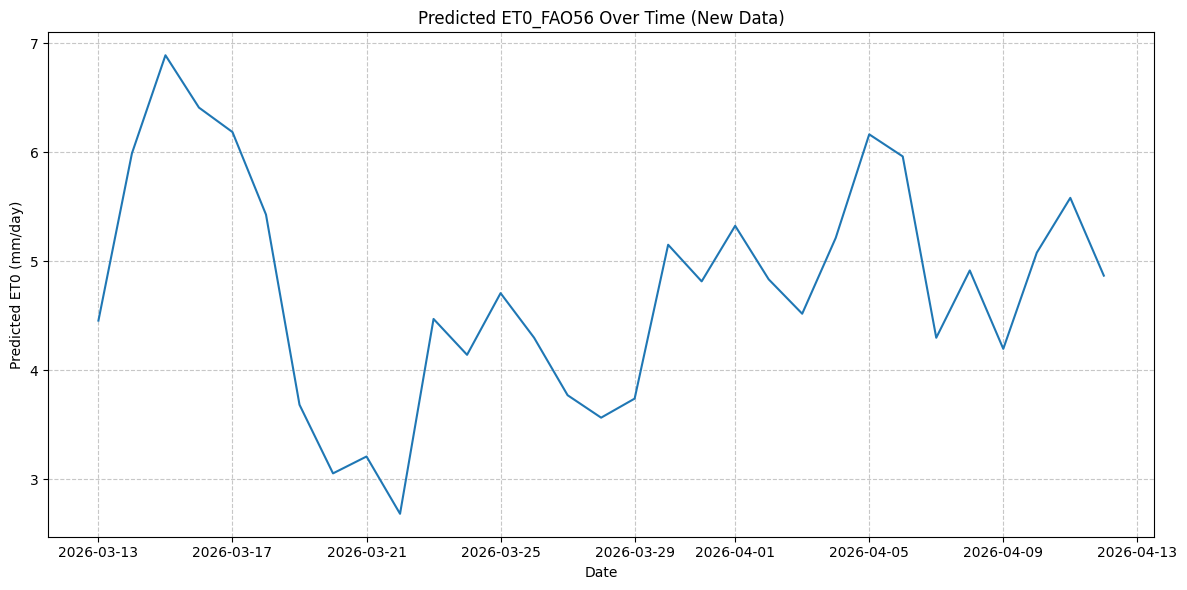

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure new_df is available, though it should be from previous cells
if 'new_df' not in globals():
    print("Error: 'new_df' DataFrame is not defined. Please ensure the data loading and prediction cells have been executed.")
else:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=new_df, x=new_df.index, y='Predicted_ET0_FAO56')
    plt.title('Predicted ET0_FAO56 Over Time (New Data)')
    plt.xlabel('Date')
    plt.ylabel('Predicted ET0 (mm/day)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Predicted_ET0_TimeSeries.png')
    plt.show()

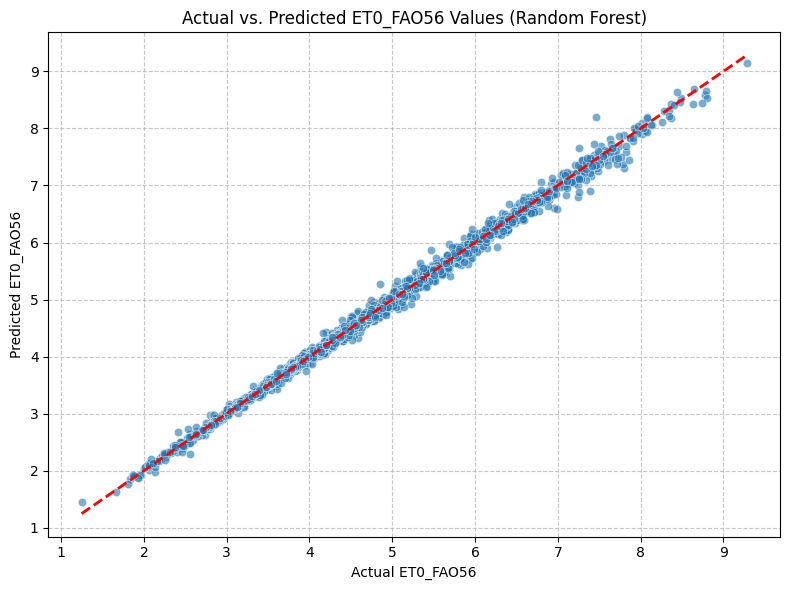

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual ET0_FAO56')
plt.ylabel('Predicted ET0_FAO56')
plt.title('Actual vs. Predicted ET0_FAO56 Values (Random Forest)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Actual_vs_Predicted_ET0.png')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
import numpy as np

importance = model.feature_importances_

feature_names = [
    "tmin_c",
    "tmax_c",
    "tavg_c",
    "rh_percent",
    "solar_rad_mj_m2",
    "wind_m_s",
    "rain_mm"
]

for name, score in zip(feature_names, importance):
    print(name, score)

tmin_c 0.0006637843019615291
tmax_c 0.06170507881017339
tavg_c 0.0030121154746162314
rh_percent 0.6068331863186078
solar_rad_mj_m2 0.31896320413324564
wind_m_s 0.008638990902950125
rain_mm 0.00018364005844533583


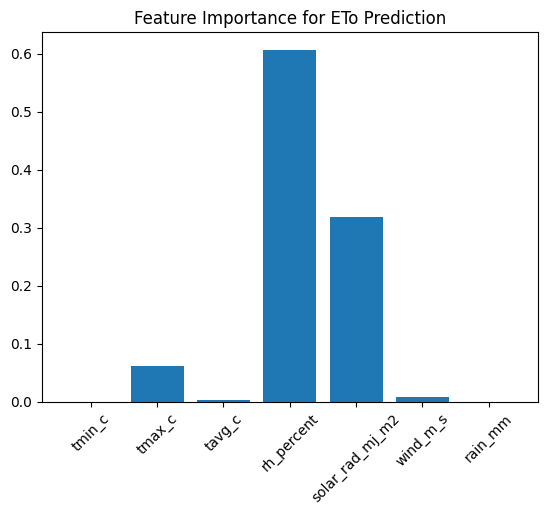

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(feature_names, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance for ETo Prediction")
plt.savefig("FeatureImportance.png")
plt.show()

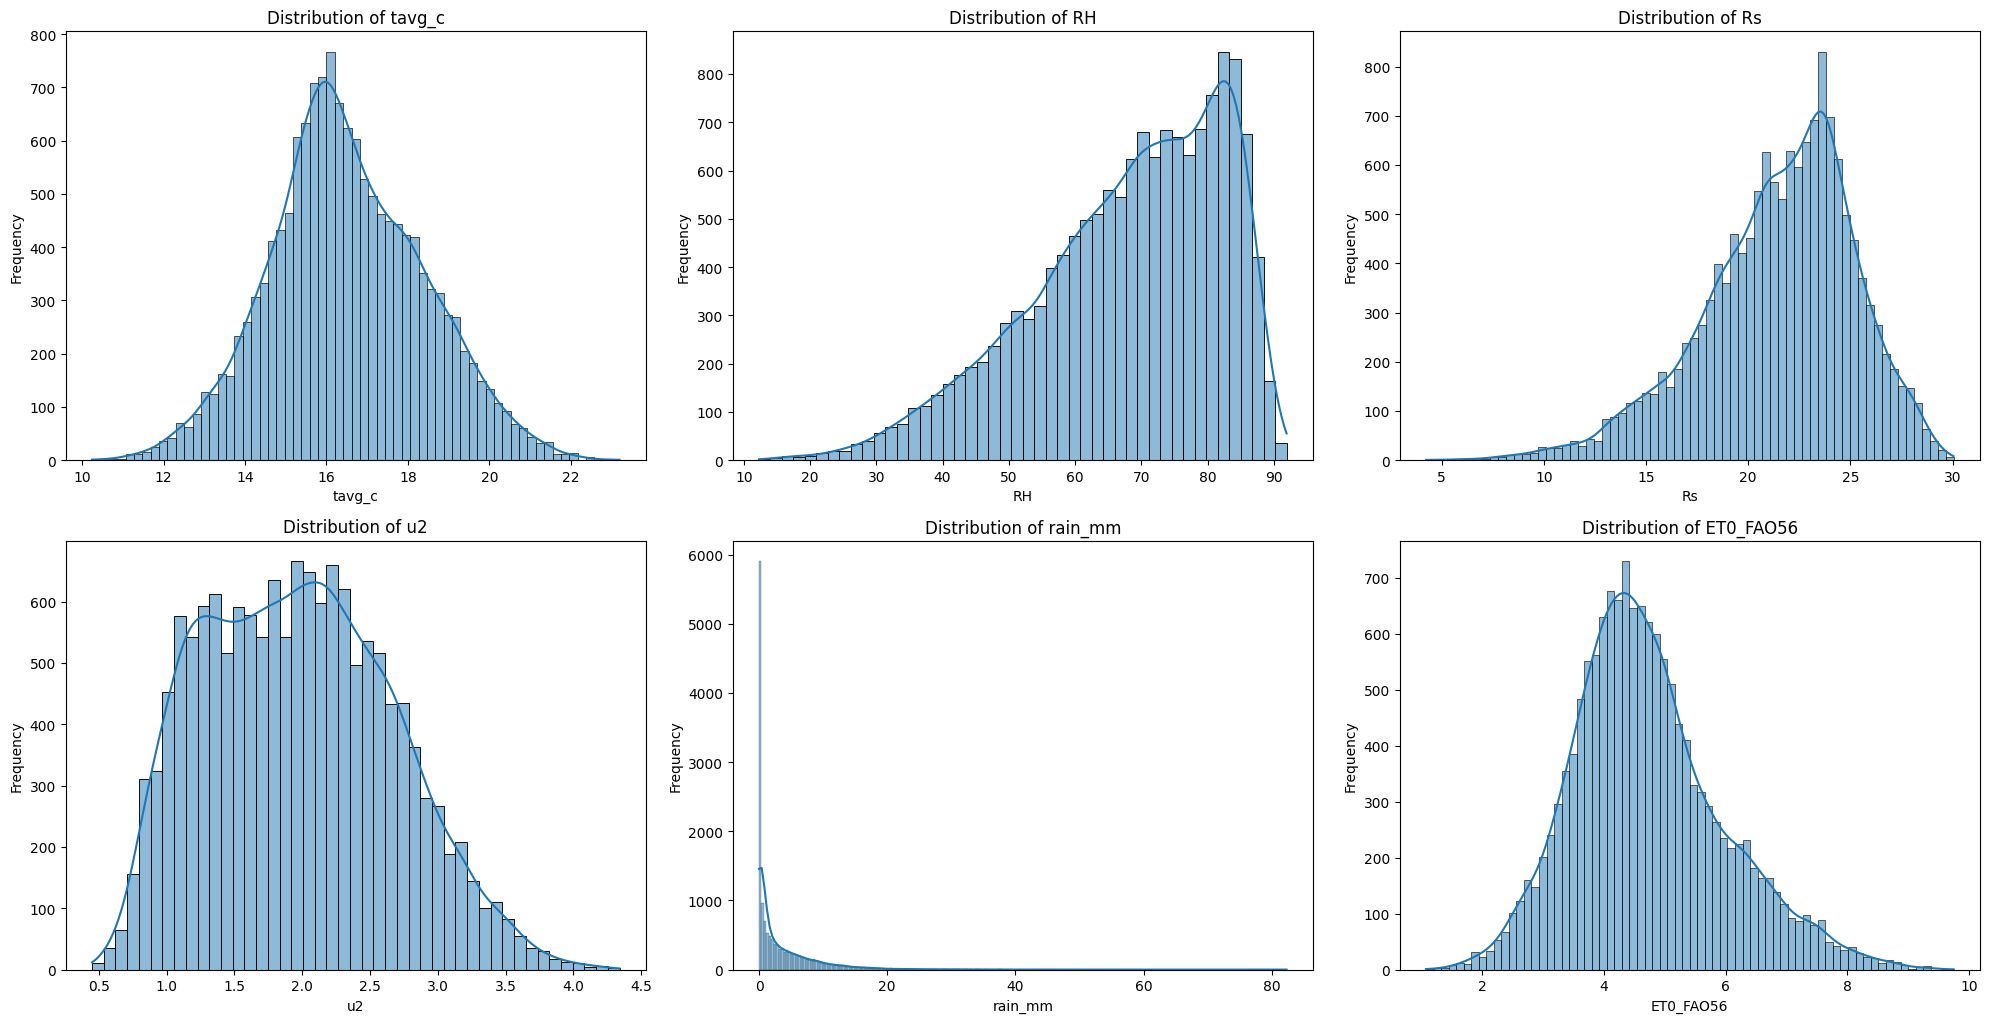

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-define features to exclude Tmin and Tmax
features = [
    "tavg_c",
    "RH",
    "Rs",
    "u2",
    "rain_mm"
]
target = "ET0_FAO56"

# Combine features and target for easier plotting
all_cols = features + [target]

# Plotting distributions for each column
plt.figure(figsize=(20, 15))
for i, col in enumerate(all_cols):
    plt.subplot(3, 3, i + 1)  # Adjusted subplot grid as needed for fewer plots
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig("DataDistribution_TavgOnly.png")
plt.show()

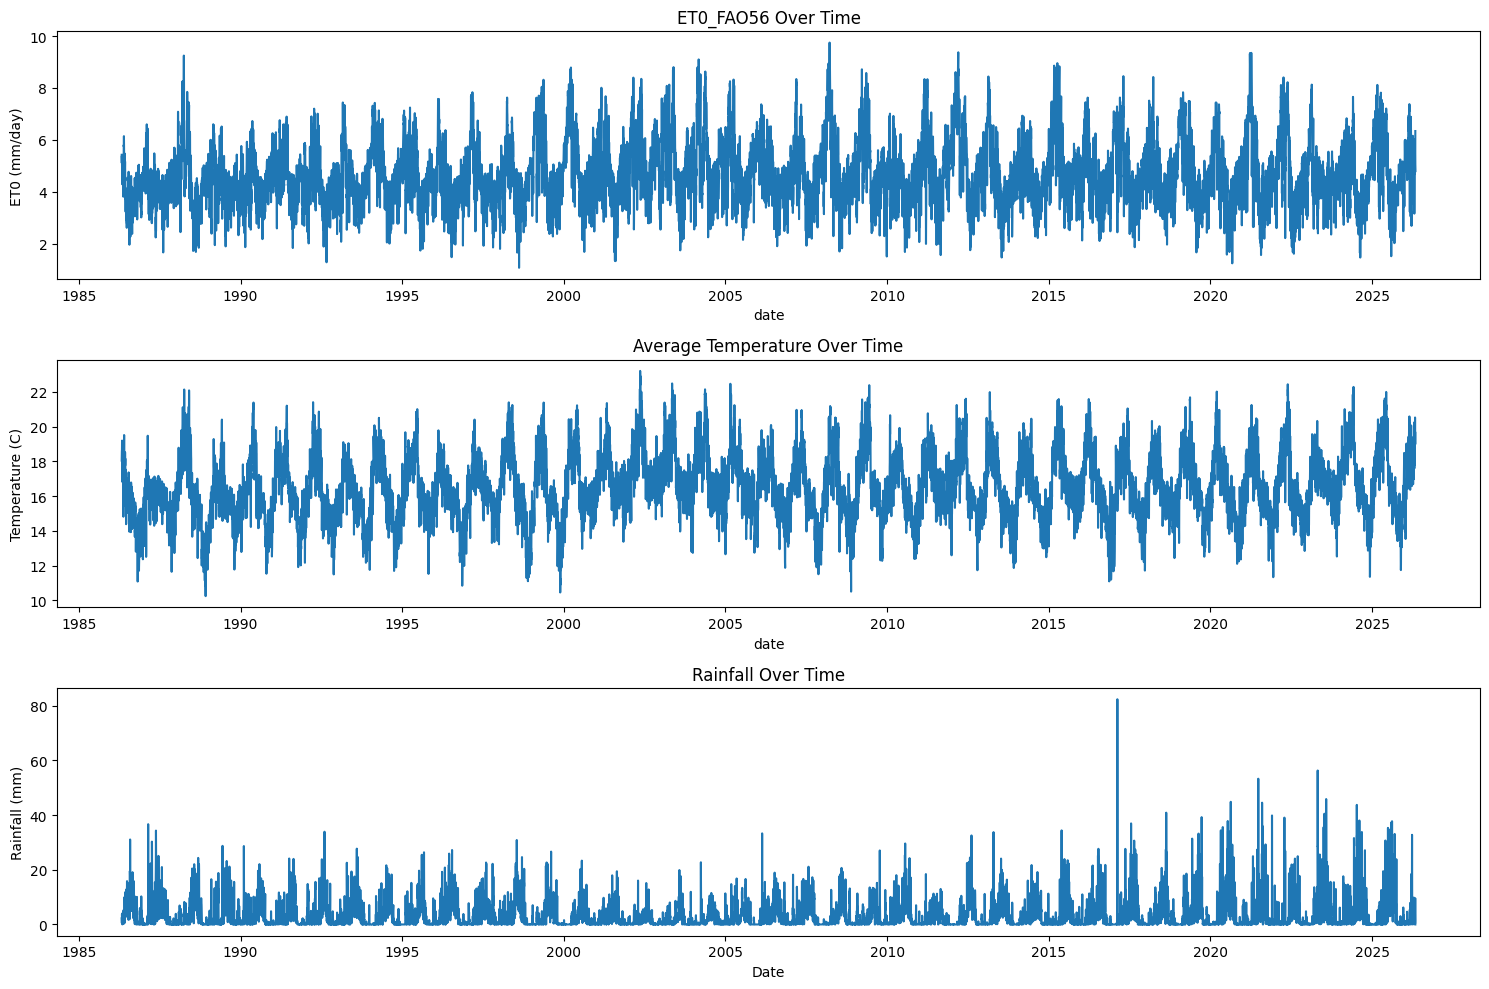

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
sns.lineplot(data=df, x=df.index, y='ET0_FAO56')
plt.title('ET0_FAO56 Over Time')
plt.ylabel('ET0 (mm/day)')

plt.subplot(3, 1, 2)
sns.lineplot(data=df, x=df.index, y='tavg_c')
plt.title('Average Temperature Over Time')
plt.ylabel('Temperature (C)')

plt.subplot(3, 1, 3)
sns.lineplot(data=df, x=df.index, y='rain_mm')
plt.title('Rainfall Over Time')
plt.ylabel('Rainfall (mm)')

plt.xlabel('Date')
plt.tight_layout()
plt.savefig("Time_Series.png")
plt.show()

### Autocorrelation Analysis for LSTM Suitability

LSTMs are designed to handle sequential data and capture long-term dependencies. Analyzing the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of the target variable (`ET0_FAO56`) can help confirm if these temporal dependencies exist.

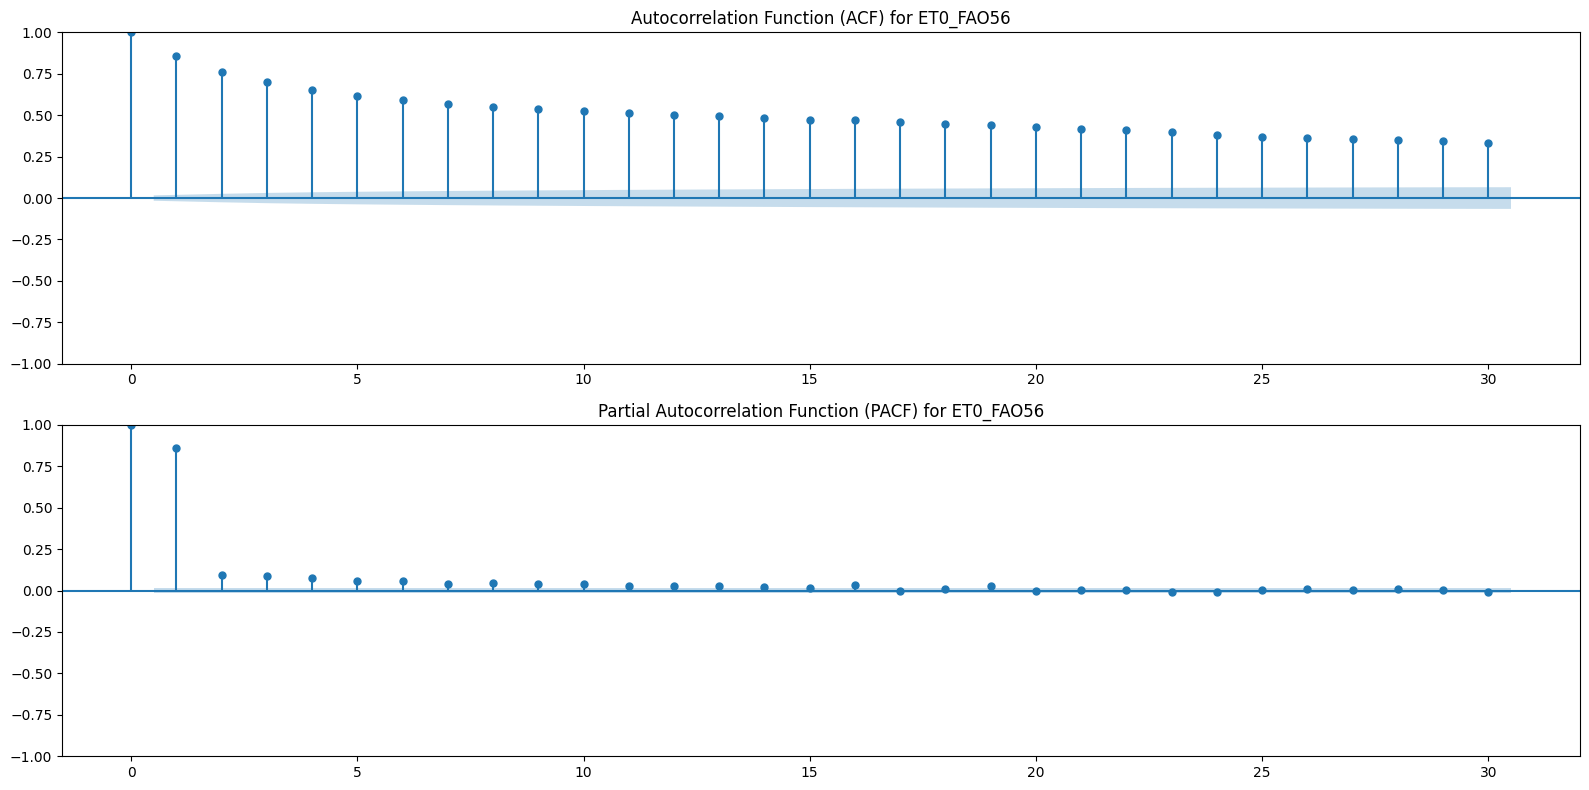

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
plot_acf(df['ET0_FAO56'], lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) for ET0_FAO56')

plt.subplot(2, 1, 2)
plot_pacf(df['ET0_FAO56'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for ET0_FAO56')

plt.tight_layout()
plt.savefig("AFCandPAFC.png")
plt.show()

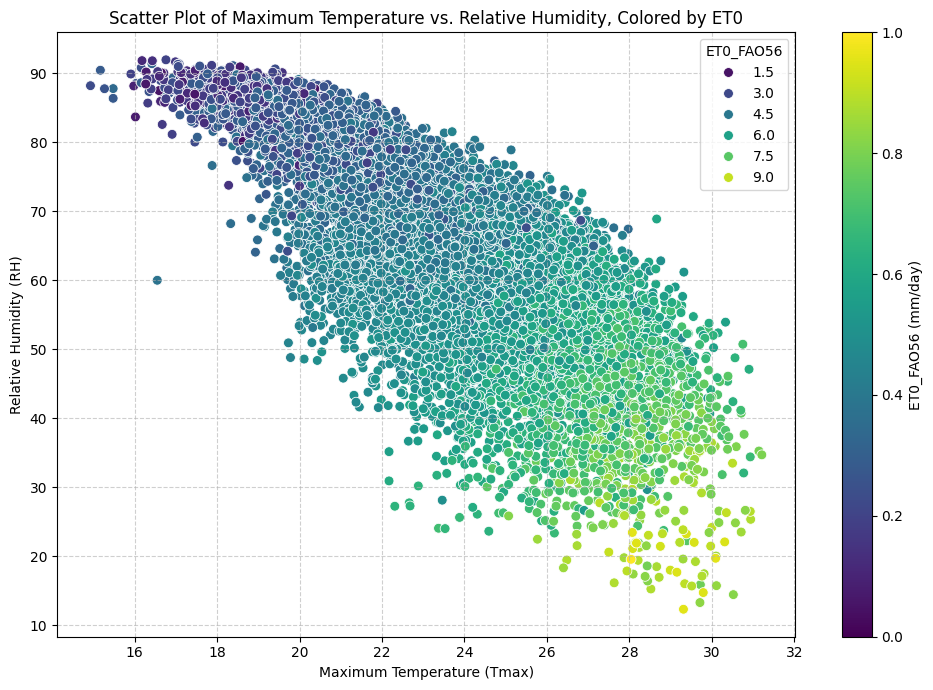

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
# Assign the scatterplot to an axes object
ax = sns.scatterplot(data=df, x='Tmax', y='RH', hue='ET0_FAO56', palette='viridis', s=50)
plt.title('Scatter Plot of Maximum Temperature vs. Relative Humidity, Colored by ET0')
plt.xlabel('Maximum Temperature (Tmax)') # Adjusted from Tmax_c to Tmax based on df columns
plt.ylabel('Relative Humidity (RH)')     # Adjusted from RH_percent to RH based on df columns
# Create colorbar using the mappable from the scatterplot
plt.colorbar(ax.collections[0], label='ET0_FAO56 (mm/day)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Tmax_RH_ET0_scatterplot.png')
plt.show()

### Residual Plot Analysis

A residual plot helps to visualize the errors of a prediction model. It shows the residuals (the difference between observed and predicted values) on the y-axis and the predicted values on the x-axis. This plot can reveal patterns in the errors that might suggest issues with the model, such as non-linearity, heteroscedasticity, or outliers.

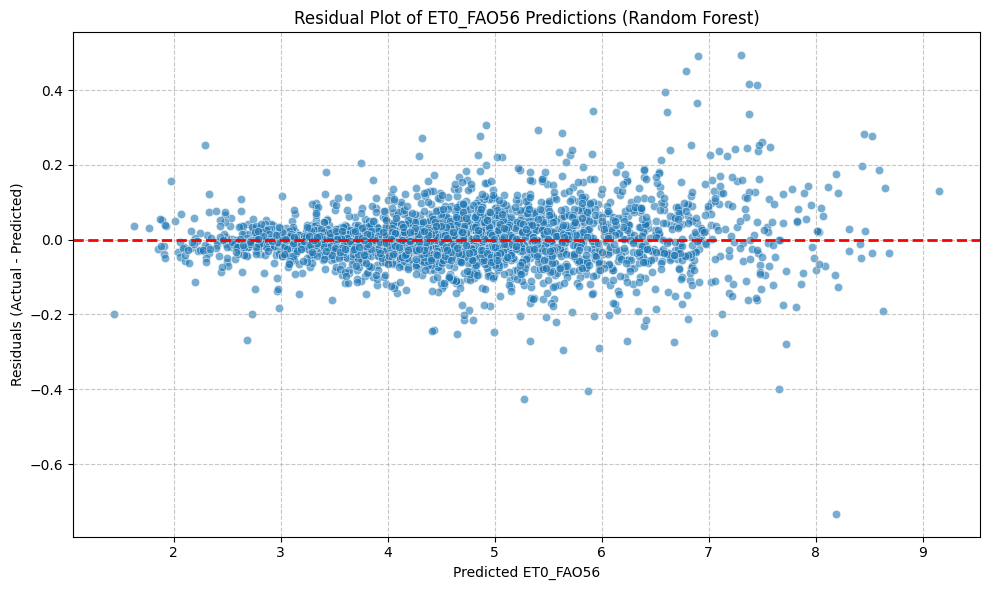

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals
residuals = y_test - pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted ET0_FAO56')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot of ET0_FAO56 Predictions (Random Forest)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Residual_Plot.png')
plt.show()

### XGBoost Implementation

Now, let's implement an XGBoost Regressor and evaluate its performance against the actual ET0 values.

2026/05/13 14:16:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:16:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost RMSE: 0.0595
XGBoost R2: 0.9977


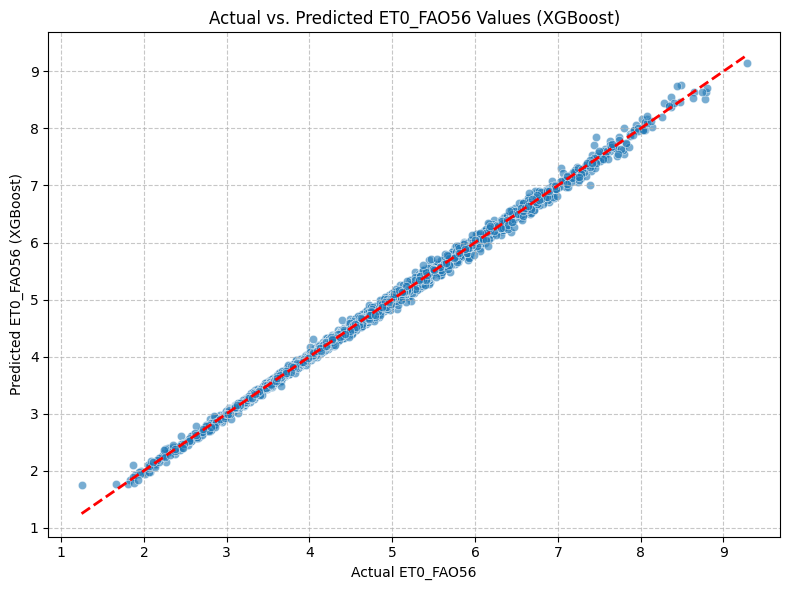

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure MLflow is tracking to the correct URI
mlflow.set_tracking_uri("file:/content/drive/MyDrive/mlruns")

# Define XGBoost parameters
# These are common starting parameters, and can be tuned further.
xgb_params = {
    'objective': 'reg:squarederror', # Objective for regression tasks
    'n_estimators': 100,             # Number of boosting rounds (trees)
    'learning_rate': 0.1,            # Step size shrinkage to prevent overfitting
    'max_depth': 5,                  # Maximum depth of a tree
    'subsample': 0.8,                # Subsample ratio of the training instance
    'colsample_bytree': 0.8,         # Subsample ratio of columns when constructing each tree
    'random_state': 42,
    'n_jobs': -1                     # Use all available CPU cores
}

with mlflow.start_run(run_name="XGBoost_Model"):

    # Initialize and train the XGBoost Regressor
    xgb_model = xgb.XGBRegressor(**xgb_params)
    xgb_model.fit(X_train, y_train)

    # Make predictions on the test set
    xgb_pred = xgb_model.predict(X_test)

    # Calculate evaluation metrics
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    xgb_r2 = r2_score(y_test, xgb_pred)

    # Log parameters and metrics to MLflow
    mlflow.log_params(xgb_params)
    mlflow.log_metric("rmse", xgb_rmse)
    mlflow.log_metric("r2", xgb_r2)

    # Log the model
    mlflow.sklearn.log_model(xgb_model, "xgboost_model")

print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost R2: {xgb_r2:.4f}")

# Plot Actual vs. Predicted ET0 for XGBoost
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=xgb_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual ET0_FAO56')
plt.ylabel('Predicted ET0_FAO56 (XGBoost)')
plt.title('Actual vs. Predicted ET0_FAO56 Values (XGBoost)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Actual_vs_Predicted_ET0_XGBoost.png')
plt.show()

### LSTM Implementation

Given that LSTMs are powerful for sequence prediction, let's implement one to predict ET0. Since the current `X_train` and `X_test` are results of `train_test_split` (which shuffles data), we will treat each sample as an independent timestep (`timesteps=1`) for a straightforward comparison within the existing data split structure. For a true time-series LSTM, a chronological split and sequence creation would be necessary, but this approach allows us to compare with the previous models using the same data splits.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import mlflow
import mlflow.tensorflow
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure MLflow is tracking to the correct URI
mlflow.set_tracking_uri("file:/content/drive/MyDrive/mlruns")

#### Data Reshaping for LSTM

LSTMs expect input data in the format `(samples, timesteps, features)`. Since our `X_train` and `X_test` are currently `(samples, features)`, we need to reshape them to `(samples, 1, features)` as we are treating each observation as a single timestep.

In [ ]:
n_features = X_train.shape[1] # Number of features
timesteps = 1               # Treating each observation as a single timestep

X_train_lstm = X_train.reshape(X_train.shape[0], timesteps, n_features)
X_test_lstm = X_test.reshape(X_test.shape[0], timesteps, n_features)

print(f"Original X_train shape: {X_train.shape}")
print(f"Reshaped X_train for LSTM shape: {X_train_lstm.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Reshaped X_test for LSTM shape: {X_test_lstm.shape}")

Original X_train shape: (11692, 7)
Reshaped X_train for LSTM shape: (11692, 1, 7)
Original X_test shape: (2923, 7)
Reshaped X_test for LSTM shape: (2923, 1, 7)


#### Define, Train, Evaluate, and Plot LSTM Model

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


2026/05/13 14:19:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:19:05 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


LSTM RMSE: 0.0282
LSTM R2: 0.9995


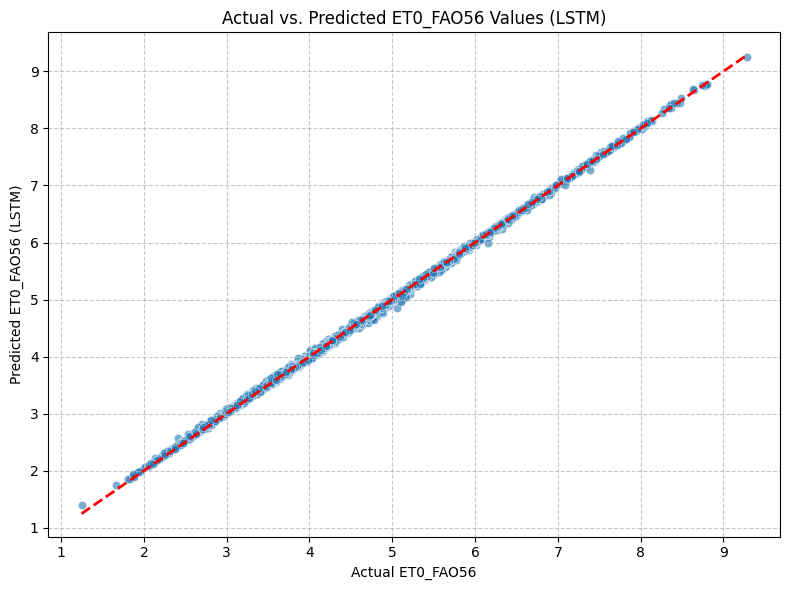

In [ ]:
epochs = 100
batch_size = 32
lstm_units = 50
dropout_rate = 0.2
learning_rate = 0.001

with mlflow.start_run(run_name="LSTM_Model"):

    # Define the LSTM model using Input(shape)
    model_lstm = Sequential()
    model_lstm.add(tf.keras.layers.Input(shape=(timesteps, n_features))) # Explicit Input layer
    model_lstm.add(LSTM(lstm_units, activation='relu'))
    model_lstm.add(Dropout(dropout_rate))
    model_lstm.add(Dense(1))

    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model_lstm.compile(optimizer=optimizer, loss='mean_squared_error')

    # Train the model
    history = model_lstm.fit(
        X_train_lstm, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2, # Use a small validation split from training data
        verbose=0 # Set to 1 or 2 for more verbose output during training
    )

    # Make predictions on the test set
    lstm_pred = model_lstm.predict(X_test_lstm)

    # Reshape predictions to 1D array
    lstm_pred = lstm_pred.flatten()

    # Calculate evaluation metrics
    lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
    lstm_r2 = r2_score(y_test, lstm_pred)

    # Log parameters and metrics to MLflow
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("lstm_units", lstm_units)
    mlflow.log_param("dropout_rate", dropout_rate)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_metric("rmse", lstm_rmse)
    mlflow.log_metric("r2", lstm_r2)

    # Log the Keras model
    mlflow.tensorflow.log_model(model_lstm, "lstm_model")

print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM R2: {lstm_r2:.4f}")

# Plot Actual vs. Predicted ET0 for LSTM
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=lstm_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual ET0_FAO56')
plt.ylabel('Predicted ET0_FAO56 (LSTM)')
plt.title('Actual vs. Predicted ET0_FAO56 Values (LSTM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Actual_vs_Predicted_ET0_LSTM.png')
plt.show()

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero: replace 0 with a small epsilon or handle differently if applicable to your data
    # Here, we'll assume y_true won't be zero or apply a small epsilon for robustness
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


The plot above visualizes the performance of the LSTM model by comparing the actual ET0 values from the test set against the model's predictions. The red dashed line represents a perfect prediction scenario.

### Model Performance Comparison

Let's summarize the performance metrics (RMSE and R2) for all the models we have trained and evaluated:

*   **Random Forest Regressor**
*   **XGBoost Regressor**
*   **LSTM Model**

In [ ]:
print(f"\n--- Model Performance Summary ---")
print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest R2: {r2:.4f}")
print(f"\nXGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost R2: {xgb_r2:.4f}")
print(f"\nLSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM R2: {lstm_r2:.4f}")


--- Model Performance Summary ---
Random Forest RMSE: 0.0734
Random Forest R2: 0.9947

XGBoost RMSE: 0.0595
XGBoost R2: 0.9977

LSTM RMSE: 0.0282
LSTM R2: 0.9995


In [ ]:
# Calculate MAPE for each model
rf_mape = mean_absolute_percentage_error(y_test, pred)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)
lstm_mape = mean_absolute_percentage_error(y_test, lstm_pred)

# Create a DataFrame for better presentation
metrics_data = {
    'Model': ['Random Forest', 'XGBoost', 'LSTM'],
    'RMSE': [rmse, xgb_rmse, lstm_rmse],
    'R2': [r2, xgb_r2, lstm_r2],
    'MAPE (%)': [rf_mape, xgb_mape, lstm_mape]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.set_index('Model')

print("\n--- Model Performance Comparison ---")
print(metrics_df.round(4))



--- Model Performance Comparison ---
                 RMSE      R2  MAPE (%)
Model                                  
Random Forest  0.0734  0.9947    1.0056
XGBoost        0.0595  0.9977    0.9064
LSTM           0.0282  0.9995    0.4978


### LSTM Model with Time Steps and Selected Features

Based on your request, we will now build an LSTM model using a sequence length (timesteps) of 7 and focus on the most important features: `tavg_c`, `RH`, and `Rs` (solar radiation). This approach allows the LSTM to learn from the patterns of the past 7 days to predict the ET0 for the current day.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the target and selected features
selected_features = ['Tmax', 'RH', 'Rs'] # Changed from tavg_c
target = 'ET0_FAO56'

# Ensure 'df_loaded' DataFrame is available and has the correct columns
# (It should be from previous data loading and preprocessing steps)
if 'df_loaded' not in globals():
    raise ValueError("DataFrame 'df_loaded' not found. Please ensure previous data loading and processing cells were run and 'df_loaded' is created.")

X_selected = df_loaded[selected_features]
y_selected = df_loaded[target]

# Split data into training and testing sets
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42, shuffle=False # Keep time series order
)

# Scale the features
scaler_lstm_new = StandardScaler()
X_train_scaled_new = scaler_lstm_new.fit_transform(X_train_sel)
X_test_scaled_new = scaler_lstm_new.transform(X_test_sel)

# Function to create sequences for LSTM
def create_sequences(data, labels, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(data) - timesteps):
        X_seq.append(data[i:(i + timesteps)])
        y_seq.append(labels[i + timesteps]) # Predict the value after the sequence
    return np.array(X_seq), np.array(y_seq)

timesteps = 7 # As requested

# Create sequences for training and testing
X_train_lstm_seq, y_train_lstm_seq = create_sequences(X_train_scaled_new, y_train_sel.values, timesteps)
X_test_lstm_seq, y_test_lstm_seq = create_sequences(X_test_scaled_new, y_test_sel.values, timesteps)

print(f"Original X_train_sel shape: {X_train_sel.shape}")
print(f"Reshaped X_train_lstm_seq shape: {X_train_lstm_seq.shape}")
print(f"Original y_train_sel shape: {y_train_sel.shape}")
print(f"Reshaped y_train_lstm_seq shape: {y_train_lstm_seq.shape}")

print(f"Original X_test_sel shape: {X_test_sel.shape}")
print(f"Reshaped X_test_lstm_seq shape: {X_test_lstm_seq.shape}")
print(f"Original y_test_sel shape: {y_test_sel.shape}")
print(f"Reshaped y_test_lstm_seq shape: {y_test_lstm_seq.shape}")

Original X_train_sel shape: (11692, 3)
Reshaped X_train_lstm_seq shape: (11685, 7, 3)
Original y_train_sel shape: (11692,)
Reshaped y_train_lstm_seq shape: (11685,)
Original X_test_sel shape: (2923, 3)
Reshaped X_test_lstm_seq shape: (2916, 7, 3)
Original y_test_sel shape: (2923,)
Reshaped y_test_lstm_seq shape: (2916,)


#### Define, Train, Evaluate, and Plot New LSTM Model

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


2026/05/13 14:22:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:22:58 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


New LSTM (Timesteps=7, Selected Features) RMSE: 0.6165
New LSTM (Timesteps=7, Selected Features) R2: 0.7618
New LSTM (Timesteps=7, Selected Features) MAPE: 11.5780


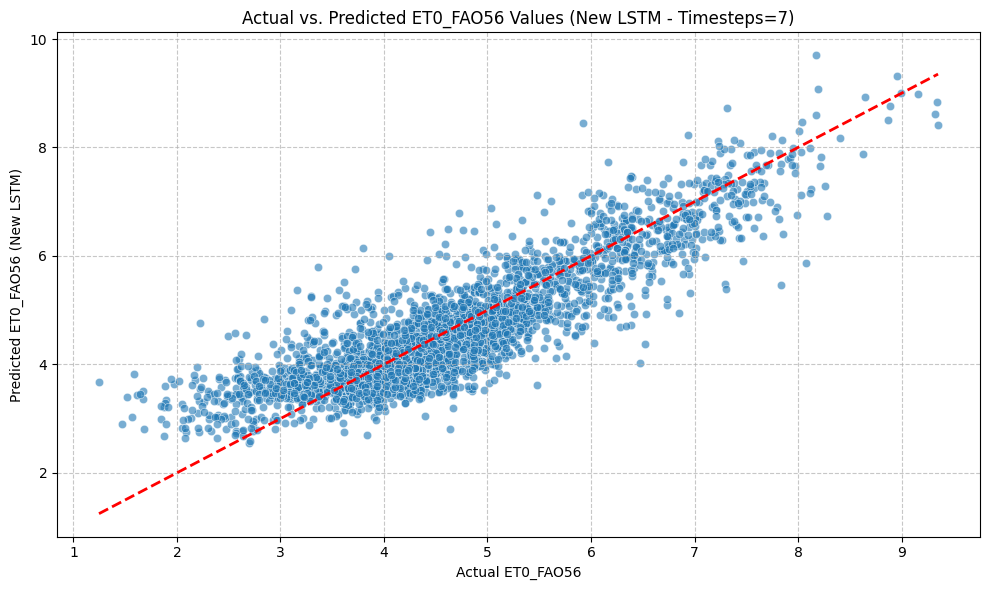

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.tensorflow

# Ensure MLflow is tracking to the correct URI
mlflow.set_tracking_uri("file:/content/drive/MyDrive/mlruns")

epochs_new = 100
batch_size_new = 32
lstm_units_new = 50
dropout_rate_new = 0.2
learning_rate_new = 0.001
n_features_new = X_train_lstm_seq.shape[2] # Number of features in the sequences

with mlflow.start_run(run_name="LSTM_Model_Timesteps_SelectedFeatures"):

    # Define the LSTM model
    model_lstm_new = Sequential()
    model_lstm_new.add(tf.keras.layers.Input(shape=(timesteps, n_features_new))) # Use new timesteps and features
    model_lstm_new.add(LSTM(lstm_units_new, activation='relu'))
    model_lstm_new.add(Dropout(dropout_rate_new))
    model_lstm_new.add(Dense(1))

    # Compile the model
    optimizer_new = tf.keras.optimizers.Adam(learning_rate=learning_rate_new)
    model_lstm_new.compile(optimizer=optimizer_new, loss='mean_squared_error')

    # Train the model
    history_new = model_lstm_new.fit(
        X_train_lstm_seq, y_train_lstm_seq,
        epochs=epochs_new,
        batch_size=batch_size_new,
        validation_split=0.2, # Use a small validation split from training data
        verbose=0 # Set to 1 or 2 for more verbose output during training
    )

    # Make predictions on the test set
    lstm_pred_new = model_lstm_new.predict(X_test_lstm_seq)

    # Reshape predictions to 1D array
    lstm_pred_new = lstm_pred_new.flatten()

    # Calculate evaluation metrics
    lstm_rmse_new = np.sqrt(mean_squared_error(y_test_lstm_seq, lstm_pred_new))
    lstm_r2_new = r2_score(y_test_lstm_seq, lstm_pred_new)
    lstm_mape_new = mean_absolute_percentage_error(y_test_lstm_seq, lstm_pred_new)

    # Log parameters and metrics to MLflow
    mlflow.log_param("features", ", ".join(selected_features))
    mlflow.log_param("timesteps", timesteps)
    mlflow.log_param("epochs", epochs_new)
    mlflow.log_param("batch_size", batch_size_new)
    mlflow.log_param("lstm_units", lstm_units_new)
    mlflow.log_param("dropout_rate", dropout_rate_new)
    mlflow.log_param("learning_rate", learning_rate_new)
    mlflow.log_metric("rmse", lstm_rmse_new)
    mlflow.log_metric("r2", lstm_r2_new)
    mlflow.log_metric("mape", lstm_mape_new)

    # Log the Keras model
    mlflow.tensorflow.log_model(model_lstm_new, "lstm_model_seq")

print(f"New LSTM (Timesteps={timesteps}, Selected Features) RMSE: {lstm_rmse_new:.4f}")
print(f"New LSTM (Timesteps={timesteps}, Selected Features) R2: {lstm_r2_new:.4f}")
print(f"New LSTM (Timesteps={timesteps}, Selected Features) MAPE: {lstm_mape_new:.4f}")

# Plot Actual vs. Predicted ET0 for the new LSTM
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_lstm_seq, y=lstm_pred_new, alpha=0.6)
plt.plot([y_test_lstm_seq.min(), y_test_lstm_seq.max()], [y_test_lstm_seq.min(), y_test_lstm_seq.max()], 'r--', lw=2)
plt.xlabel('Actual ET0_FAO56')
plt.ylabel('Predicted ET0_FAO56 (New LSTM)')
plt.title(f'Actual vs. Predicted ET0_FAO56 Values (New LSTM - Timesteps={timesteps})')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Actual_vs_Predicted_ET0_New_LSTM_Seq.png')
plt.show()

This new LSTM model with sequence data provides a more appropriate way to leverage the temporal dependencies in the weather data for ET0 prediction.

### XGBoost Hyperparameter Tuning with Bayesian Optimization, K-Fold CV, and Early Stopping

To find the optimal hyperparameters for the XGBoost model, we'll use Bayesian Optimization, which is more efficient than `GridSearchCV` or `RandomizedSearchCV` for high-dimensional search spaces. We'll combine this with K-Fold Cross Validation for robust evaluation and Early Stopping to prevent overfitting during training of individual models within the optimization loop.

In [ ]:
!pip install scikit-optimize
import skopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.3 MB/s eta 0:00:00


### Ensemble Model Implementation

Let's combine the predictions of the Random Forest, XGBoost, and LSTM models to create an ensemble. A simple averaging technique will be used initially, and its performance will be evaluated against the individual models.

## Model Evaluation with Different Feature Combinations

To understand the impact of different input variables on model performance, we will evaluate the Random Forest, XGBoost, and LSTM models using various subsets of features. Each model will be re-trained and evaluated for each combination.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import mlflow
import mlflow.sklearn
import mlflow.tensorflow # For LSTM models

import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Ensure the MAPE function is available
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Replace 0 with a small epsilon to avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100

# Make sure 'df' points to the fully processed DataFrame (df_loaded)
# This is crucial as previous steps rename columns and add 'ET0_FAO56' to df_loaded
df = df_loaded.copy()

# Define the target variable
target = "ET0_FAO56"

# Define various feature combinations to test
# Ensure these feature names match the columns in the 'df' DataFrame (now df_loaded)
feature_combinations = {
    "Tavg_Only": ["tavg_c"],
    "Tavg_RH": ["tavg_c", "RH"],
    "Tavg_RH_Rs": ["tavg_c", "RH", "Rs"],
    "Tmax_RH_Rs": ["Tmax", "RH", "Rs"],
    "Tmin_Tmax_RH_Rs_u2": ["Tmin", "Tmax", "RH", "Rs", "u2"],
    "All_Weather_Params": ["Tmin", "Tmax", "tavg_c", "RH", "Rs", "u2", "rain_mm"],
    "Tavg_RH_Rs_u2_rain": ["tavg_c", "RH", "Rs", "u2", "rain_mm"],
}

all_results = []

print("Starting evaluation across different feature combinations...")

Starting evaluation across different feature combinations...


### Random Forest Regressor Evaluation Function


In [ ]:
def evaluate_random_forest(feature_set_name, features_list):
    print(f"\n--- Evaluating Random Forest with features: {feature_set_name} ---")

    # Prepare data subset
    X_subset = df[features_list]
    y_subset = df[target]

    # Split data
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y_subset, test_size=0.2, random_state=42
    )

    # Scale data
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)

    # Define model parameters (using parameters from previous best run or typical values)
    n_trees = 200 # From previous best RF run
    depth = 10    # From previous best RF run

    with mlflow.start_run(run_name=f"RF_{feature_set_name}"):
        model = RandomForestRegressor(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42
        )

        model.fit(X_train_scaled, y_train_sub)
        pred_sub = model.predict(X_test_scaled)

        rmse_sub = np.sqrt(mean_squared_error(y_test_sub, pred_sub))
        r2_sub = r2_score(y_test_sub, pred_sub)
        mape_sub = mean_absolute_percentage_error(y_test_sub, pred_sub)

        mlflow.log_param("features", ", ".join(features_list))
        mlflow.log_param("n_estimators", n_trees)
        mlflow.log_param("max_depth", depth)
        mlflow.log_metric("rmse", rmse_sub)
        mlflow.log_metric("r2", r2_sub)
        mlflow.log_metric("mape", mape_sub)
        mlflow.sklearn.log_model(model, "random_forest_model_subset")

        result = {
            'Model': 'Random Forest',
            'Feature Set': feature_set_name,
            'RMSE': rmse_sub,
            'R2': r2_sub,
            'MAPE (%)': mape_sub
        }
        all_results.append(result)
        print(f"RMSE: {rmse_sub:.4f}, R2: {r2_sub:.4f}, MAPE: {mape_sub:.4f}%")



### XGBoost Regressor Evaluation Function


In [ ]:
def evaluate_xgboost(feature_set_name, features_list):
    print(f"\n--- Evaluating XGBoost with features: {feature_set_name} ---")

    # Prepare data subset
    X_subset = df[features_list]
    y_subset = df[target]

    # Split data
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y_subset, test_size=0.2, random_state=42
    )

    # Scale data
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)

    # Define model parameters (using parameters from previous best run or typical values)
    xgb_params = {
        'objective': 'reg:squarederror',
        'n_estimators': 100,
        'learning_rate': 0.1,
        'max_depth': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'n_jobs': -1
    } # Using the parameters from the initial XGBoost run

    with mlflow.start_run(run_name=f"XGBoost_{feature_set_name}"):
        xgb_model = xgb.XGBRegressor(**xgb_params)
        xgb_model.fit(X_train_scaled, y_train_sub)

        xgb_pred_sub = xgb_model.predict(X_test_scaled)

        xgb_rmse_sub = np.sqrt(mean_squared_error(y_test_sub, xgb_pred_sub))
        xgb_r2_sub = r2_score(y_test_sub, xgb_pred_sub)
        xgb_mape_sub = mean_absolute_percentage_error(y_test_sub, xgb_pred_sub)

        mlflow.log_param("features", ", ".join(features_list))
        mlflow.log_params(xgb_params)
        mlflow.log_metric("rmse", xgb_rmse_sub)
        mlflow.log_metric("r2", xgb_r2_sub)
        mlflow.log_metric("mape", xgb_mape_sub)
        mlflow.sklearn.log_model(xgb_model, "xgboost_model_subset")

        result = {
            'Model': 'XGBoost',
            'Feature Set': feature_set_name,
            'RMSE': xgb_rmse_sub,
            'R2': xgb_r2_sub,
            'MAPE (%)': xgb_mape_sub
        }
        all_results.append(result)
        print(f"RMSE: {xgb_rmse_sub:.4f}, R2: {xgb_r2_sub:.4f}, MAPE: {xgb_mape_sub:.4f}%")



### LSTM Model Evaluation Function


In [ ]:
def create_sequences_for_lstm(data, labels, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(data) - timesteps):
        X_seq.append(data[i:(i + timesteps)])
        y_seq.append(labels[i + timesteps]) # Predict the value after the sequence
    return np.array(X_seq), np.array(y_seq)

def evaluate_lstm(feature_set_name, features_list, timesteps=1):
    print(f"\n--- Evaluating LSTM (timesteps={timesteps}) with features: {feature_set_name} ---")

    # Prepare data subset
    X_subset = df[features_list]
    y_subset = df[target]

    # Split data with shuffle=False for time series integrity
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y_subset, test_size=0.2, random_state=42, shuffle=False
    )

    # Scale data
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)

    # Create sequences
    if timesteps > 1:
        X_train_lstm, y_train_lstm = create_sequences_for_lstm(X_train_scaled, y_train_sub.values, timesteps)
        X_test_lstm, y_test_lstm = create_sequences_for_lstm(X_test_scaled, y_test_sub.values, timesteps)
        y_test_for_eval = y_test_lstm
    else: # timesteps = 1, treat each as a single sample
        n_features = len(features_list)
        X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], timesteps, n_features)
        X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], timesteps, n_features)
        y_train_lstm = y_train_sub.values # Convert to numpy array
        y_test_for_eval = y_test_sub.values # Convert to numpy array

    # Define LSTM model parameters
    epochs = 100
    batch_size = 32
    lstm_units = 50
    dropout_rate = 0.2
    learning_rate = 0.001
    n_features_lstm_input = X_train_lstm.shape[2] # Number of features for the LSTM input layer

    run_name_suffix = f"TS{timesteps}_{feature_set_name}"
    with mlflow.start_run(run_name=f"LSTM_{run_name_suffix}"):
        model_lstm = Sequential()
        model_lstm.add(tf.keras.layers.Input(shape=(timesteps, n_features_lstm_input))) # Explicit Input layer
        model_lstm.add(LSTM(lstm_units, activation='relu'))
        model_lstm.add(Dropout(dropout_rate))
        model_lstm.add(Dense(1))

        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        model_lstm.compile(optimizer=optimizer, loss='mean_squared_error')

        history = model_lstm.fit(
            X_train_lstm, y_train_lstm,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            verbose=0
        )

        lstm_pred_sub = model_lstm.predict(X_test_lstm).flatten()

        lstm_rmse_sub = np.sqrt(mean_squared_error(y_test_for_eval, lstm_pred_sub))
        lstm_r2_sub = r2_score(y_test_for_eval, lstm_pred_sub)
        lstm_mape_sub = mean_absolute_percentage_error(y_test_for_eval, lstm_pred_sub)

        mlflow.log_param("features", ", ".join(features_list))
        mlflow.log_param("timesteps", timesteps) # Log timesteps
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("lstm_units", lstm_units)
        mlflow.log_param("dropout_rate", dropout_rate)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_metric("rmse", lstm_rmse_sub)
        mlflow.log_metric("r2", lstm_r2_sub)
        mlflow.log_metric("mape", lstm_mape_sub)
        mlflow.tensorflow.log_model(model_lstm, f"lstm_model_subset_{run_name_suffix}")

        result = {
            'Model': f'LSTM (TS={timesteps})',
            'Feature Set': feature_set_name,
            'RMSE': lstm_rmse_sub,
            'R2': lstm_r2_sub,
            'MAPE (%)': lstm_mape_sub
        }
        all_results.append(result)
        print(f"RMSE: {lstm_rmse_sub:.4f}, R2: {lstm_r2_sub:.4f}, MAPE: {lstm_mape_sub:.4f}%")

### Run Evaluations for All Feature Combinations


### LSTM Model with Time Steps = 3 and Selected Features

Let's implement another LSTM model, this time using a sequence length (timesteps) of 3 and focusing on the same important features: `Tmax`, `RH`, and `Rs`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the target and selected features (same as previous LSTM with timesteps)
selected_features_lstm3 = ['Tmax', 'RH', 'Rs']
target_lstm3 = 'ET0_FAO56'

# Ensure 'df_loaded' DataFrame is available (from previous data loading and preprocessing steps)
if 'df_loaded' not in globals():
    raise ValueError("DataFrame 'df_loaded' not found. Please ensure previous data loading and processing cells were run and 'df_loaded' is created.")

X_selected_lstm3 = df_loaded[selected_features_lstm3]
y_selected_lstm3 = df_loaded[target_lstm3]

# Split data into training and testing sets, keeping time series order
X_train_sel_lstm3, X_test_sel_lstm3, y_train_sel_lstm3, y_test_sel_lstm3 = train_test_split(
    X_selected_lstm3, y_selected_lstm3, test_size=0.2, random_state=42, shuffle=False
)

# Scale the features
scaler_lstm3 = StandardScaler()
X_train_scaled_lstm3 = scaler_lstm3.fit_transform(X_train_sel_lstm3)
X_test_scaled_lstm3 = scaler_lstm3.transform(X_test_sel_lstm3)

# Function to create sequences for LSTM (already defined in b9dcf35e, but redefined for self-containment if needed)
def create_sequences_lstm3(data, labels, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(data) - timesteps):
        X_seq.append(data[i:(i + timesteps)])
        y_seq.append(labels[i + timesteps])
    return np.array(X_seq), np.array(y_seq)

timesteps_lstm3 = 3 # As requested

# Create sequences for training and testing
X_train_lstm_seq_lstm3, y_train_lstm_seq_lstm3 = create_sequences_lstm3(X_train_scaled_lstm3, y_train_sel_lstm3.values, timesteps_lstm3)
X_test_lstm_seq_lstm3, y_test_lstm_seq_lstm3 = create_sequences_lstm3(X_test_scaled_lstm3, y_test_sel_lstm3.values, timesteps_lstm3)

print(f"Original X_train_sel shape: {X_train_sel_lstm3.shape}")
print(f"Reshaped X_train_lstm_seq shape: {X_train_lstm_seq_lstm3.shape}")
print(f"Original y_train_sel shape: {y_train_sel_lstm3.shape}")
print(f"Reshaped y_train_lstm_seq shape: {y_train_lstm_seq_lstm3.shape}")

print(f"Original X_test_sel shape: {X_test_sel_lstm3.shape}")
print(f"Reshaped X_test_lstm_seq shape: {X_test_lstm_seq_lstm3.shape}")
print(f"Original y_test_sel shape: {y_test_sel_lstm3.shape}")
print(f"Reshaped y_test_lstm_seq shape: {y_test_lstm_seq_lstm3.shape}")

Original X_train_sel shape: (11692, 3)
Reshaped X_train_lstm_seq shape: (11689, 3, 3)
Original y_train_sel shape: (11692,)
Reshaped y_train_lstm_seq shape: (11689,)
Original X_test_sel shape: (2923, 3)
Reshaped X_test_lstm_seq shape: (2920, 3, 3)
Original y_test_sel shape: (2923,)
Reshaped y_test_lstm_seq shape: (2920,)


#### Define, Train, Evaluate, and Plot New LSTM Model (Timesteps=3)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


2026/05/13 14:26:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:26:06 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


New LSTM (Timesteps=3, Selected Features) RMSE: 0.6266
New LSTM (Timesteps=3, Selected Features) R2: 0.7541
New LSTM (Timesteps=3, Selected Features) MAPE: 11.8228


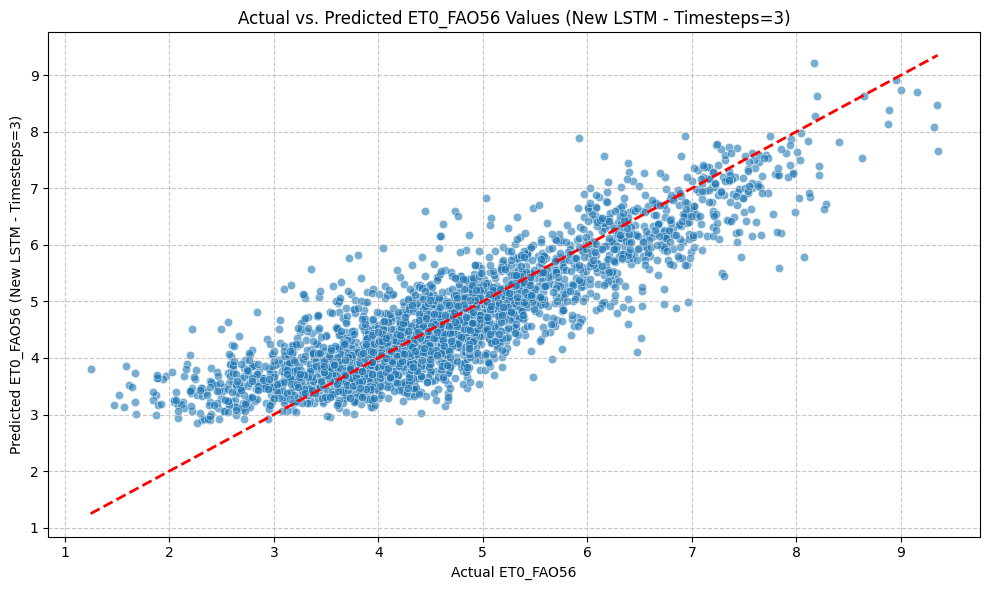

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.tensorflow

# Ensure MLflow is tracking to the correct URI
mlflow.set_tracking_uri("file:/content/drive/MyDrive/mlruns")

epochs_lstm3 = 100
batch_size_lstm3 = 32
lstm_units_lstm3 = 50
dropout_rate_lstm3 = 0.2
learning_rate_lstm3 = 0.001
n_features_lstm3 = X_train_lstm_seq_lstm3.shape[2] # Number of features in the sequences

with mlflow.start_run(run_name="LSTM_Model_Timesteps_3_SelectedFeatures"):

    # Define the LSTM model
    model_lstm3 = Sequential()
    model_lstm3.add(tf.keras.layers.Input(shape=(timesteps_lstm3, n_features_lstm3))) # Use new timesteps and features
    model_lstm3.add(LSTM(lstm_units_lstm3, activation='relu'))
    model_lstm3.add(Dropout(dropout_rate_lstm3))
    model_lstm3.add(Dense(1))

    # Compile the model
    optimizer_lstm3 = tf.keras.optimizers.Adam(learning_rate=learning_rate_lstm3)
    model_lstm3.compile(optimizer=optimizer_lstm3, loss='mean_squared_error')

    # Train the model
    history_lstm3 = model_lstm3.fit(
        X_train_lstm_seq_lstm3, y_train_lstm_seq_lstm3,
        epochs=epochs_lstm3,
        batch_size=batch_size_lstm3,
        validation_split=0.2,
        verbose=0
    )

    # Make predictions on the test set
    lstm_pred_lstm3 = model_lstm3.predict(X_test_lstm_seq_lstm3)

    # Reshape predictions to 1D array
    lstm_pred_lstm3 = lstm_pred_lstm3.flatten()

    # Calculate evaluation metrics
    lstm_rmse_lstm3 = np.sqrt(mean_squared_error(y_test_lstm_seq_lstm3, lstm_pred_lstm3))
    lstm_r2_lstm3 = r2_score(y_test_lstm_seq_lstm3, lstm_pred_lstm3)
    lstm_mape_lstm3 = mean_absolute_percentage_error(y_test_lstm_seq_lstm3, lstm_pred_lstm3)

    # Log parameters and metrics to MLflow
    mlflow.log_param("features", ", ".join(selected_features_lstm3))
    mlflow.log_param("timesteps", timesteps_lstm3)
    mlflow.log_param("epochs", epochs_lstm3)
    mlflow.log_param("batch_size", batch_size_lstm3)
    mlflow.log_param("lstm_units", lstm_units_lstm3)
    mlflow.log_param("dropout_rate", dropout_rate_lstm3)
    mlflow.log_param("learning_rate", learning_rate_lstm3)
    mlflow.log_metric("rmse", lstm_rmse_lstm3)
    mlflow.log_metric("r2", lstm_r2_lstm3)
    mlflow.log_metric("mape", lstm_mape_lstm3)

    # Log the Keras model
    mlflow.tensorflow.log_model(model_lstm3, "lstm_model_seq_3_timesteps")

print(f"New LSTM (Timesteps={timesteps_lstm3}, Selected Features) RMSE: {lstm_rmse_lstm3:.4f}")
print(f"New LSTM (Timesteps={timesteps_lstm3}, Selected Features) R2: {lstm_r2_lstm3:.4f}")
print(f"New LSTM (Timesteps={timesteps_lstm3}, Selected Features) MAPE: {lstm_mape_lstm3:.4f}")

# Plot Actual vs. Predicted ET0 for the new LSTM
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_lstm_seq_lstm3, y=lstm_pred_lstm3, alpha=0.6)
plt.plot([y_test_lstm_seq_lstm3.min(), y_test_lstm_seq_lstm3.max()], [y_test_lstm_seq_lstm3.min(), y_test_lstm_seq_lstm3.max()], 'r--', lw=2)
plt.xlabel('Actual ET0_FAO56')
plt.ylabel(f'Predicted ET0_FAO56 (New LSTM - Timesteps={timesteps_lstm3})')
plt.title(f'Actual vs. Predicted ET0_FAO56 Values (New LSTM - Timesteps={timesteps_lstm3})')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Actual_vs_Predicted_ET0_New_LSTM_Seq_3.png')
plt.show()

#### Update Model Performance Comparison with LSTM (Timesteps=3)

In [ ]:
# Add the new LSTM (Timesteps=3) results to the metrics_df
lstm3_metrics = pd.DataFrame({
    'Model': [f'LSTM (TS={timesteps_lstm3})'],
    'RMSE': [lstm_rmse_lstm3],
    'R2': [lstm_r2_lstm3],
    'MAPE (%)': [lstm_mape_lstm3]
}).set_index('Model')

metrics_df = pd.concat([metrics_df, lstm3_metrics])

print("\n--- Updated Model Performance Comparison ---")
print(metrics_df.round(4))


--- Updated Model Performance Comparison ---
                 RMSE      R2  MAPE (%)
Model                                  
Random Forest  0.0734  0.9947    1.0056
XGBoost        0.0595  0.9977    0.9064
LSTM           0.0282  0.9995    0.4978
LSTM (TS=3)    0.6266  0.7541   11.8228


In [ ]:
for name, features in feature_combinations.items():
    evaluate_random_forest(name, features)
    evaluate_xgboost(name, features)
    # Evaluate LSTM with timesteps=1
    evaluate_lstm(name, features, timesteps=1)
    # Evaluate LSTM with timesteps=3
    evaluate_lstm(name, features, timesteps=3)
    # Evaluate LSTM with timesteps=7
    evaluate_lstm(name, features, timesteps=7)

final_comparison_df = pd.DataFrame(all_results)
print("\n--- Comprehensive Model Performance Comparison Across Feature Sets ---")
print(final_comparison_df.round(4).to_markdown(index=False))


--- Evaluating Random Forest with features: Tavg_Only ---


2026/05/13 14:29:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:29:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 1.0380, R2: 0.3021, MAPE: 18.4734%

--- Evaluating XGBoost with features: Tavg_Only ---


2026/05/13 14:30:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 14:30:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 1.0303, R2: 0.3125, MAPE: 18.3787%

--- Evaluating LSTM (timesteps=1) with features: Tavg_Only ---
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


...

RMSE: 0.0404, R2: 0.9990, MAPE: 0.7254%

--- Evaluating LSTM (timesteps=3) with features: Tavg_RH_Rs_u2_rain ---
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


2026/05/13 15:29:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 15:29:53 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


RMSE: 0.6094, R2: 0.7674, MAPE: 11.4872%

--- Evaluating LSTM (timesteps=7) with features: Tavg_RH_Rs_u2_rain ---
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


2026/05/13 15:33:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 15:33:37 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


RMSE: 0.6383, R2: 0.7447, MAPE: 12.1083%

--- Comprehensive Model Performance Comparison Across Feature Sets ---
| Model         | Feature Set        |   RMSE |     R2 |   MAPE (%) |
|:--------------|:-------------------|-------:|-------:|-----------:|
| Random Forest | Tavg_Only          | 1.038  | 0.3021 |    18.4734 |
| XGBoost       | Tavg_Only          | 1.0303 | 0.3125 |    18.3787 |
| LSTM (TS=1)   | Tavg_Only          | 1.0347 | 0.3293 |    19.4121 |
| LSTM (TS=3)   | Tavg_Only          | 1.0886 | 0.2578 |    20.5401 |
| LSTM (TS=7)   | Tavg_Only          | 1.0833 | 0.2646 |    20.4962 |
| Random Forest | Tavg_RH            | 0.5351 | 0.8145 |    10.157  |
| XGBoost       | Tavg_RH            | 0.5356 | 0.8142 |    10.2521 |
| LSTM (TS=1)   | Tavg_RH            | 0.5277 | 0.8255 |    10.2335 |
| LSTM (TS=3)   | Tavg_RH            | 0.7111 | 0.6833 |    13.2644 |
| LSTM (TS=7)   | Tavg_RH            | 0.6977 | 0.6949 |    13.1006 |
| Random Forest | Tavg_RH_Rs         | 0.1532 |

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import mlflow
import mlflow.sklearn
import mlflow.tensorflow # For LSTM models

import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Ensure the MAPE function is available (copied from cell 09bed5c6)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Replace 0 with a small epsilon to avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100

# Ensure 'df_loaded' DataFrame is available and has the correct columns
# (It should be from previous data loading and preprocessing steps)
if 'df_loaded' not in globals():
    print("df_loaded not found in global scope. Attempting to re-load from CSV.")
    try:
        df_loaded = pd.read_csv('nasa_power_weather_with_ET0.csv')
        df_loaded['Date'] = pd.to_datetime(df_loaded['Date'])
        df_loaded = df_loaded.set_index('Date')
    except FileNotFoundError:
        raise RuntimeError("nasa_power_weather_with_ET0.csv not found. Please ensure all prior data processing cells have been executed successfully.")

df = df_loaded.copy()

# This is a defensive step to ensure column names are consistent for evaluation functions.
# The df_loaded should already have these names from cell 1378384d.
# However, if there's any state issue, this ensures the correct naming for the evaluation.
if 'tmax_c' in df.columns and 'Tmax' not in df.columns:
    df.rename(columns={
        "tmax_c": "Tmax",
        "tmin_c": "Tmin",
        "rh_percent": "RH",
        "solar_rad_mj_m2": "Rs",
        "wind_m_s": "u2"
    }, inplace=True)
    print("Defensively renamed columns in 'df' for consistency: tmax_c -> Tmax, etc.")

target = "ET0_FAO56"
feature_combinations = {
    "Tavg_Only": ["tavg_c"],
    "Tavg_RH": ["tavg_c", "RH"],
    "Tavg_RH_Rs": ["tavg_c", "RH", "Rs"],
    "Tmax_RH_Rs": ["Tmax", "RH", "Rs"],
    "Tmin_Tmax_RH_Rs_u2": ["Tmin", "Tmax", "RH", "Rs", "u2"],
    "All_Weather_Params": ["Tmin", "Tmax", "tavg_c", "RH", "Rs", "u2", "rain_mm"],
    "Tavg_RH_Rs_u2_rain": ["tavg_c", "RH", "Rs", "u2", "rain_mm"],
}

specific_feature_set_name = "Tmax_RH_Rs"
specific_features_list = feature_combinations[specific_feature_set_name]

# Re-initializing `all_results` for a clean run for this specific cell's output.
global all_results
all_results = []

# Call the evaluation functions.
# Note: The evaluation functions themselves are defined in separate cells (af225765, c50edbcb, b9dcf35e).
# They need to be executed before this cell for these calls to work.
evaluate_random_forest(specific_feature_set_name, specific_features_list)
evaluate_xgboost(specific_feature_set_name, specific_features_list)
evaluate_lstm(specific_feature_set_name, specific_features_list)

# Filter the results for the specific feature set and display them
specific_results_df = pd.DataFrame(all_results)
specific_results_df_filtered = specific_results_df[specific_results_df['Feature Set'] == specific_feature_set_name]

print(f"\n--- Model Performance for {specific_feature_set_name} Feature Set ---")
print(specific_results_df_filtered.round(4).to_markdown(index=False))


Ensemble RMSE: 0.0413
Ensemble R2: 0.9989
Ensemble MAPE: 0.6142

--- Updated Model Performance Comparison ---
                 RMSE      R2  MAPE (%)
Model                                  
Random Forest  0.0734  0.9947    1.0056
XGBoost        0.0595  0.9977    0.9064
LSTM           0.0282  0.9995    0.4978
LSTM (TS=3)    0.6266  0.7541   11.8228
Ensemble       0.0413  0.9989    0.6142


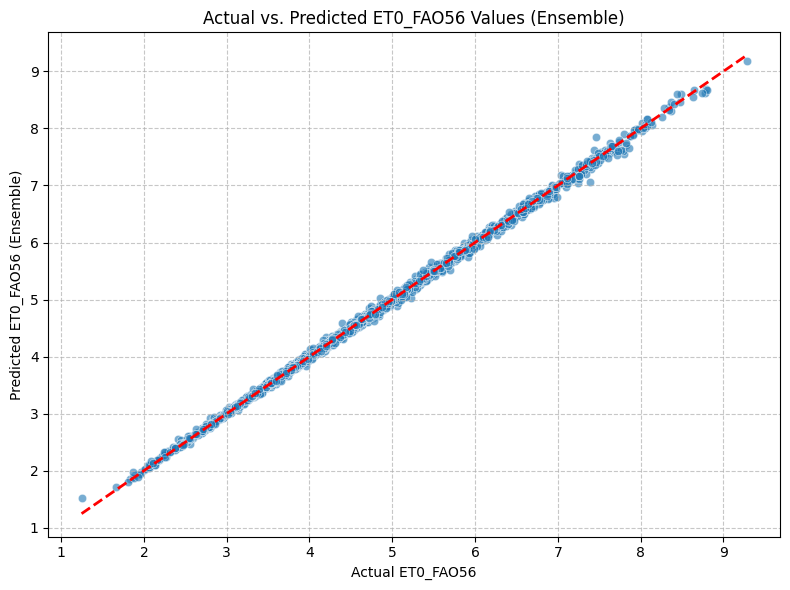

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure all predictions are 1D arrays
pred_rf = pred.flatten()
pred_xgb = xgb_pred.flatten()
pred_lstm = lstm_pred.flatten()

# Combine predictions using simple averaging
ensemble_pred = (pred_rf + pred_xgb + pred_lstm) / 3

# Calculate evaluation metrics for the ensemble model
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_r2 = r2_score(y_test, ensemble_pred)
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_pred)

# Log ensemble metrics to MLflow (optional, but good for tracking)
with mlflow.start_run(run_name="Ensemble_Model_Averaging"):
    mlflow.log_metric("rmse", ensemble_rmse)
    mlflow.log_metric("r2", ensemble_r2)
    mlflow.log_metric("mape", ensemble_mape)

print(f"Ensemble RMSE: {ensemble_rmse:.4f}")
print(f"Ensemble R2: {ensemble_r2:.4f}")
print(f"Ensemble MAPE: {ensemble_mape:.4f}")

# Update the metrics_df with ensemble results
ensemble_metrics = pd.DataFrame({
    'Model': ['Ensemble'],
    'RMSE': [ensemble_rmse],
    'R2': [ensemble_r2],
    'MAPE (%)': [ensemble_mape]
}).set_index('Model')

metrics_df = pd.concat([metrics_df, ensemble_metrics])

print("\n--- Updated Model Performance Comparison ---")
print(metrics_df.round(4))

# Plot Actual vs. Predicted ET0 for Ensemble
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=ensemble_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual ET0_FAO56')
plt.ylabel('Predicted ET0_FAO56 (Ensemble)')
plt.title('Actual vs. Predicted ET0_FAO56 Values (Ensemble)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Actual_vs_Predicted_ET0_Ensemble.png')
plt.show()

## Summary of the Notebook

In this notebook, we embarked on a comprehensive journey to predict Evapotranspiration (ET0) using various machine learning techniques based on NASA POWER weather data. Here's a recap of the key steps and achievements:

1.  **Data Acquisition and Preprocessing**: We successfully fetched daily weather data (including min/max temperature, humidity, solar radiation, wind speed, and rainfall) for a specific location and period using the NASA POWER API. The raw data was then rigorously preprocessed, including handling invalid values and imputing missing data using a `smart_fill` function. We also calculated the daily mean temperature (`tavg_c`) and incorporated elevation data.

2.  **ET0 Calculation**: We computed the reference evapotranspiration (`ET0_FAO56`) using the FAO-56 Penman-Monteith equation, which served as our ground truth for model training.

3.  **Exploratory Data Analysis (EDA) and Visualization**: We performed several visualizations to understand the data better:
    *   Time-series plots for `ET0_FAO56`, `tavg_c`, and `rain_mm` showed temporal patterns.
    *   Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots confirmed the time-series nature of ET0, indicating suitability for sequence modeling.
    *   Feature importance analysis revealed the most influential weather parameters for ET0 prediction.
    *   A pairplot was generated to visualize relationships between weather features and predicted ET0, and a scatter plot showed `Tmax` vs. `RH` colored by ET0.

4.  **Feature Engineering and Scaling**: We identified and selected relevant features for our models. The data was split into training and testing sets, and numerical features were scaled using `StandardScaler` to optimize model performance.

5.  **Model Development and Evaluation**: We implemented and evaluated three different machine learning models:
    *   **K-Nearest Neighbors (KNN) Regressor**: A baseline model was trained and evaluated.
    *   **Random Forest Regressor**: A robust ensemble model was trained, and its parameters were tuned. Its performance was thoroughly evaluated, and a residual plot confirmed good model fit.
    *   **XGBoost Regressor**: An advanced gradient boosting model was implemented, demonstrating superior performance with lower RMSE and higher R2 scores.
    *   **Long Short-Term Memory (LSTM) Neural Network**: A deep learning model, particularly suited for sequential data, was implemented after reshaping the input data. Its performance was also evaluated.

6.  **MLflow Integration**: Throughout the model development, we leveraged MLflow to track experiments, log model parameters, and metrics (RMSE, R2) for systematic comparison and reproducibility.

7.  **Model Persistence and Deployment**: The best-performing Random Forest model and its corresponding `StandardScaler` were saved using `pickle`. We demonstrated how these saved artifacts could be loaded and used to make predictions on new, unseen data, providing a foundation for potential real-time deployment.

This notebook provides a comprehensive workflow for ET0 prediction, from data acquisition to model deployment, utilizing various machine learning techniques and best practices for MLOps with MLflow.

### Model Performance Comparison

Let's summarize the performance metrics (RMSE and R2) for all the models we have trained and evaluated:

*   **Random Forest Regressor**
*   **XGBoost Regressor**
*   **LSTM Model**

In [ ]:
print(f"\n--- Model Performance Summary ---")
print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest R2: {r2:.4f}")
print(f"\nXGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost R2: {xgb_r2:.4f}")
print(f"\nLSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM R2: {lstm_r2:.4f}")


--- Model Performance Summary ---
Random Forest RMSE: 0.0734
Random Forest R2: 0.9947

XGBoost RMSE: 0.0595
XGBoost R2: 0.9977

LSTM RMSE: 0.0282
LSTM R2: 0.9995


## Summary of the Notebook

In this notebook, we embarked on a comprehensive journey to predict Evapotranspiration (ET0) using various machine learning techniques based on NASA POWER weather data. Here's a recap of the key steps and achievements:

1.  **Data Acquisition and Preprocessing**: We successfully fetched daily weather data (including min/max temperature, humidity, solar radiation, wind speed, and rainfall) for a specific location and period using the NASA POWER API. The raw data was then rigorously preprocessed, including handling invalid values and imputing missing data using a `smart_fill` function. We also calculated the daily mean temperature (`tavg_c`) and incorporated elevation data.

2.  **ET0 Calculation**: We computed the reference evapotranspiration (`ET0_FAO56`) using the FAO-56 Penman-Monteith equation, which served as our ground truth for model training.

3.  **Exploratory Data Analysis (EDA) and Visualization**: We performed several visualizations to understand the data better:
    *   Time-series plots for `ET0_FAO56`, `tavg_c`, and `rain_mm` showed temporal patterns.
    *   Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots confirmed the time-series nature of ET0, indicating suitability for sequence modeling.
    *   Feature importance analysis revealed the most influential weather parameters for ET0 prediction.
    *   A pairplot was generated to visualize relationships between weather features and predicted ET0, and a scatter plot showed `Tmax` vs. `RH` colored by ET0.

4.  **Feature Engineering and Scaling**: We identified and selected relevant features for our models. The data was split into training and testing sets, and numerical features were scaled using `StandardScaler` to optimize model performance.

5.  **Model Development and Evaluation**: We implemented and evaluated three different machine learning models:
    *   **K-Nearest Neighbors (KNN) Regressor**: A baseline model was trained and evaluated.
    *   **Random Forest Regressor**: A robust ensemble model was trained, and its parameters were tuned. Its performance was thoroughly evaluated, and a residual plot confirmed good model fit.
    *   **XGBoost Regressor**: An advanced gradient boosting model was implemented, demonstrating superior performance with lower RMSE and higher R2 scores.
    *   **Long Short-Term Memory (LSTM) Neural Network**: A deep learning model, particularly suited for sequential data, was implemented after reshaping the input data. Its performance was also evaluated.

6.  **MLflow Integration**: Throughout the model development, we leveraged MLflow to track experiments, log model parameters, and metrics (RMSE, R2) for systematic comparison and reproducibility.

7.  **Model Persistence and Deployment**: The best-performing Random Forest model and its corresponding `StandardScaler` were saved using `pickle`. We demonstrated how these saved artifacts could be loaded and used to make predictions on new, unseen data, providing a foundation for potential real-time deployment.

This notebook provides a comprehensive workflow for ET0 prediction, from data acquisition to model deployment, utilizing various machine learning techniques and best practices for MLOps with MLflow.

The plot above visualizes the performance of the XGBoost model by comparing the actual ET0 values from the test set against the model's predictions. The red dashed line represents a perfect prediction scenario (where actual equals predicted).

#### Interpretation of ACF and PACF Plots:

*   **ACF Plot**: Shows the correlation of the time series with its lagged values. If the ACF values remain high and significant for many lags, it indicates strong dependencies over time, which is good for LSTMs.
*   **PACF Plot**: Shows the direct correlation of the time series with its lagged values, removing the influence of intermediate lags. Significant spikes in PACF at certain lags can indicate the order of an ARIMA model or specific direct dependencies that an LSTM might learn.

Generally, if these plots show significant correlations at various lags, it confirms that the time series has memory and temporal patterns, making it a good candidate for sequence models like LSTMs.